# Business EDA — VinDatathon 2026 Round 1
## Phân tích doanh nghiệp thời trang TMĐT Việt Nam (2012–2022)

### Framework phân tích 4 tầng chiều sâu

| Cấp độ | Câu hỏi | Mục tiêu |
|---|---|---|
| **Descriptive** | *Chuyện gì đã xảy ra?* | Thống kê đúng, biểu đồ có nhãn |
| **Diagnostic** | *Tại sao lại xảy ra?* | Giả thuyết nhân quả, join bảng, so sánh |
| **Predictive** | *Điều gì sẽ xảy ra?* | Trend, seasonality, leading indicator |
| **Prescriptive** | *Doanh nghiệp cần làm gì?* | Đề xuất định lượng, actionable, trade-off |


### Caveat bắt buộc khi đọc notebook

- `sales.Revenue` = `gross_revenue_booked` = `quantity * unit_price` theo `order_date`, all `order_status`; không trừ discount/refund/ship.
- `payments.payment_value` = `net_paid_after_discount`; dùng cho AOV, promo burn, margin theo business basis.
- `returns.refund_amount` chỉ dùng cho return-adjusted/operating proxy, không được trừ vào forecast target.
- `web_traffic.sessions` là tổng daily site-level. `traffic_source` chỉ là 1 nhãn/ngày, không phải attribution; không groupby source rồi sum sessions.

---
## 0. Nạp dữ liệu & Chuẩn bị

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

def find_project_root():
    candidates = [Path.cwd(), Path.cwd() / 'VinDatathon_the-4-Outliers', *Path.cwd().parents]
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        has_clean = (candidate / 'data' / 'clean' / 'orders.parquet').exists()
        has_raw = (candidate / 'datathon-2026-round-1' / 'orders.csv').exists()
        if has_clean or has_raw:
            return candidate
    raise FileNotFoundError('Could not locate project root containing clean parquet or raw csv data')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from theme import apply_theme, style_ax, annotate_bar, add_insight, make_legend, get_palette, colors_for, COLORS, C, SEQ_BLUE, SEQ_AMBER, DIV, CLR_TITLE, CLR_MUTED, CLR_LABEL
apply_theme()

DATA = PROJECT_ROOT / 'data' / 'clean'
FEAT = PROJECT_ROOT / 'data' / 'features'
RAW = PROJECT_ROOT / 'datathon-2026-round-1'
CLEAN = DATA
table_sources = {}

def read_table(name, parse_dates=None, rename_map=None):
    parquet_path = DATA / f'{name}.parquet'
    csv_path = RAW / f'{name}.csv'
    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
        source = 'parquet'
    elif csv_path.exists():
        df = pd.read_csv(csv_path, low_memory=False)
        source = 'csv'
    else:
        raise FileNotFoundError(f'Missing both {parquet_path.name} and {csv_path.name}')

    if rename_map:
        for old, new in rename_map.items():
            if old in df.columns and new not in df.columns:
                df = df.rename(columns={old: new})

    for col in parse_dates or []:
        if col in df.columns and not pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = pd.to_datetime(df[col], errors='coerce')

    table_sources[name] = source
    return df

products = read_table('products')
customers = read_table('customers', parse_dates=['signup_date'])
promotions = read_table('promotions', parse_dates=['start_date', 'end_date'])
geography = read_table('geography')
orders = read_table('orders', parse_dates=['order_date'])
order_items = read_table('order_items')
payments = read_table('payments')
shipments = read_table('shipments', parse_dates=['ship_date', 'delivery_date'])
returns = read_table('returns', parse_dates=['return_date'])
reviews = read_table('reviews', parse_dates=['review_date'])
sales = read_table('sales', parse_dates=['Date'], rename_map={'date': 'Date'})
inventory = read_table('inventory', parse_dates=['snapshot_date'])
web_traffic = read_table('web_traffic', parse_dates=['date'])

# Derived
sales['Gross_Profit'] = sales['Revenue'] - sales['COGS']
sales['Margin_Pct'] = sales['Gross_Profit'] / sales['Revenue'] * 100
sales['year'] = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month

# Enriched order items
oi = order_items.merge(orders[['order_id', 'order_date', 'customer_id', 'order_status']], on='order_id', how='left')
oi = oi.merge(products[['product_id', 'category', 'segment', 'size', 'price', 'cogs']], on='product_id', how='left')
oi['line_revenue'] = oi['quantity'] * oi['unit_price']
oi['line_cogs'] = oi['quantity'] * oi['cogs']
oi['line_net'] = oi['line_revenue'] - oi['discount_amount']
oi['line_gross_profit'] = oi['line_revenue'] - oi['line_cogs']
# Business margin basis: net fulfilled profit = revenue after discount minus COGS.
oi['line_profit'] = oi['line_net'] - oi['line_cogs']
oi['has_promo'] = oi['discount_amount'] > 0  # Clean parquet: promo_id='No_Promo', .notna() sai
oi['is_committed'] = ~oi['order_status'].isin(['cancelled', 'created'])
oi['year'] = oi['order_date'].dt.year
oi['month'] = oi['order_date'].dt.month

print(f"Loaded data from {PROJECT_ROOT}")
for name, df in {
    'products': products,
    'customers': customers,
    'promotions': promotions,
    'geography': geography,
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'shipments': shipments,
    'returns': returns,
    'reviews': reviews,
    'sales': sales,
    'inventory': inventory,
    'web_traffic': web_traffic,
}.items():
    print(f"  {name}: {df.shape} [{table_sources[name]}]")
print(f"Dữ liệu: {len(orders):,} đơn | {len(oi):,} dòng sản phẩm | {len(products):,} SKU | {len(customers):,} khách")
print(f"Giai đoạn: {orders['order_date'].min().date()} → {orders['order_date'].max().date()}")

def load_shared():
    """Load 3 shared feature tables from Phase 2 if available."""
    try:
        li = pd.read_parquet(FEAT / 'shared_line_items.parquet')
        sd = pd.read_parquet(FEAT / 'shared_daily.parquet')
        sc = pd.read_parquet(FEAT / 'shared_calendar.parquet')
        print('[OK] Loaded shared features from parquet')
        return li, sd, sc
    except Exception as e:
        print(f'[WARN] Shared features unavailable: {e}')
        print('[FALLBACK] Continue notebook with base tables only')
        return None, None, None

shared_line_items, shared_daily, shared_calendar = load_shared()


Vivid Slate theme applied.
Loaded data from D:\B. COMPUTER SCIENCE PROJECTS\D. DATATHON\VinDatathon_the-4-Outliers
  products: (2412, 8) [parquet]
  customers: (121930, 7) [parquet]
  promotions: (50, 10) [parquet]
  geography: (39948, 4) [parquet]
  orders: (646945, 8) [parquet]
  order_items: (714669, 7) [parquet]
  payments: (646945, 4) [parquet]
  shipments: (566067, 4) [parquet]
  returns: (39939, 7) [parquet]
  reviews: (113551, 7) [parquet]
  sales: (3833, 7) [parquet]
  inventory: (60247, 17) [parquet]
  web_traffic: (3652, 7) [parquet]
Dữ liệu: 646,945 đơn | 714,669 dòng sản phẩm | 2,412 SKU | 121,930 khách
Giai đoạn: 2012-07-04 → 2022-12-31
[OK] Loaded shared features from parquet


---
# TẦNG 1: DESCRIPTIVE — Chuyện gì đã xảy ra?

> Mục tiêu: Thống kê chính xác, biểu đồ rõ ràng, tóm lược KPI.


### 1.1 Bảng KPI tổng quan

In [2]:
# --- KPI Dashboard ---
total_rev = sales['Revenue'].sum()                 # gross booked revenue, all order_status
total_cogs = sales['COGS'].sum()                   # target COGS, all order_status
total_profit = sales['Gross_Profit'].sum()
target_gross_margin = total_profit / total_rev * 100

n_orders = orders['order_id'].nunique()
committed_orders_df = orders[~orders['order_status'].isin(['cancelled', 'created'])]
n_committed = committed_orders_df['order_id'].nunique()

committed_lines = oi[oi['is_committed']]
committed_net_rev = committed_lines['line_net'].sum()
committed_net_profit = committed_lines['line_profit'].sum()
net_committed_margin = committed_net_profit / committed_net_rev * 100

aov_net_fulfilled = committed_net_rev / n_committed  # net fulfilled AOV for business segmentation
target_gross_aov = total_rev / n_orders            # gross all-status AOV aligned with sales.Revenue

n_return_orders = returns['order_id'].nunique()
return_rate = n_return_orders / n_committed * 100  # order-level return rate over fulfilled/committed orders

yearly_rev = sales.groupby('year')['Revenue'].sum()
yoy_last = (yearly_rev.iloc[-1] / yearly_rev.iloc[-2] - 1) * 100

print("=" * 60)
print("KPI TỔNG QUAN DOANH NGHIỆP")
print("=" * 60)
print(f"  Tổng doanh thu target (gross):    {total_rev:>15,.0f}")
print(f"  Tổng giá vốn target (COGS):       {total_cogs:>15,.0f}")
print(f"  Gross profit target:              {total_profit:>15,.0f}")
print(f"  Target gross margin (weighted):   {target_gross_margin:>14.1f} %")
print(f"  Net fulfilled margin:             {net_committed_margin:>14.1f} %")
print(f"  AOV net fulfilled:                {aov_net_fulfilled:>15,.0f}")
print(f"  AOV gross target:                 {target_gross_aov:>15,.0f}")
print(f"  Tỷ lệ đơn trả hàng:              {return_rate:>14.2f} %")
print(f"  Tăng trưởng YoY (năm cuối):       {yoy_last:>+14.1f} %")
print(f"  Doanh thu trung bình/ngày:        {sales['Revenue'].mean():>15,.0f}")


KPI TỔNG QUAN DOANH NGHIỆP
  Tổng doanh thu target (gross):     16,430,476,586
  Tổng giá vốn target (COGS):        14,163,450,519
  Gross profit target:                2,267,026,066
  Target gross margin (weighted):             13.8 %
  Net fulfilled margin:                        9.7 %
  AOV net fulfilled:                         24,219
  AOV gross target:                          25,397
  Tỷ lệ đơn trả hàng:                        6.22 %
  Tăng trưởng YoY (năm cuối):                +12.1 %
  Doanh thu trung bình/ngày:              4,286,584


### 1.2 Doanh thu theo Category & Segment

DOANH THU THEO CATEGORY (Revenue_gross_booked = gross all-status | Margin_pct_net_fulfilled = net committed)


,Revenue_gross_booked,So_don,So_luong,Ty_le_%,Loi_nhuan,Margin_pct_net_fulfilled
category,,,,,,
Streetwear,1.313135e+10,389543,1768826,79.9,1.045416e+09,9.3
Outdoor,2.494883e+09,200454,1170000,15.2,2.396996e+08,11.4
Casual,4.606484e+08,23600,107469,2.8,3.051249e+07,7.7
GenZ,3.435991e+08,37054,166848,2.1,4.555022e+07,15.4


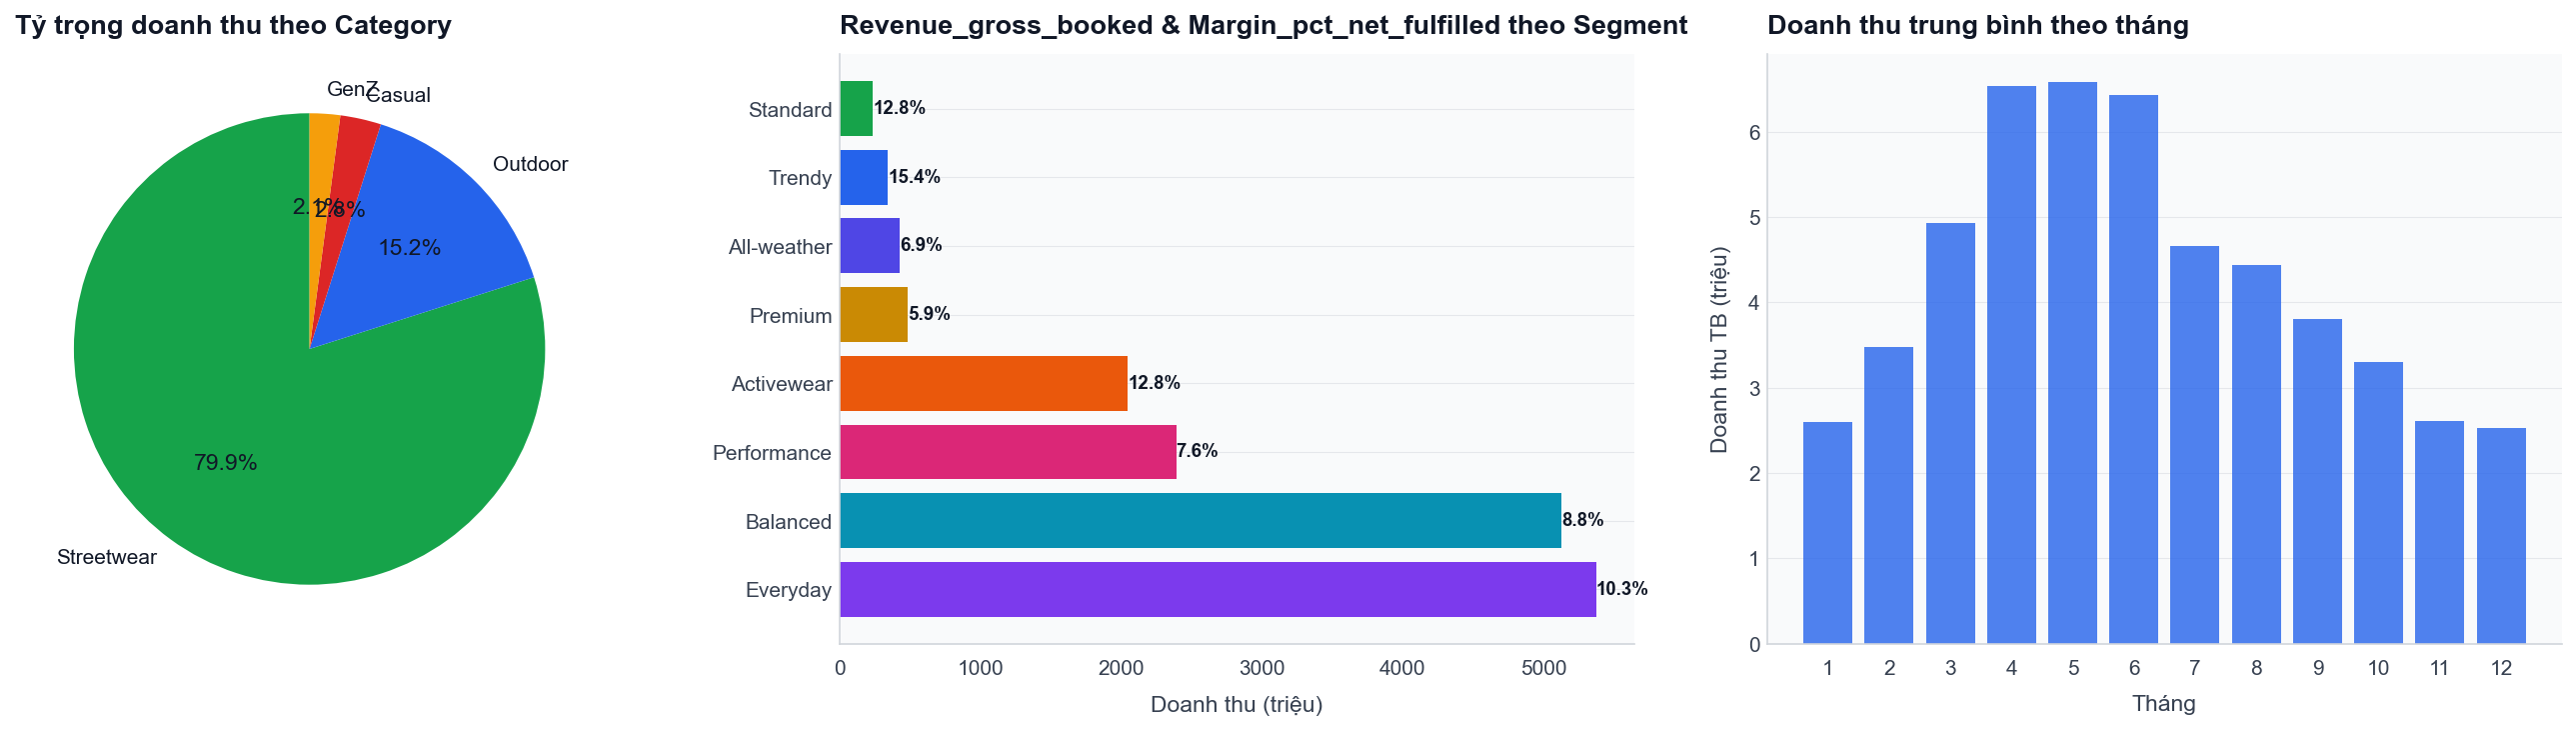


📊 NHẬN XÉT MÔ TẢ (DESCRIPTIVE):
  • Tháng 4-6 có doanh thu trung bình tăng 81% so với các tháng còn lại
  • Streetwear chiếm 79.9% doanh thu - gần như đơn ngành
  • Trendy có Margin cao nhất (15.4%) nhưng doanh thu thấp nhất


In [3]:
# --- Doanh thu chia theo Category (gross all — aligned with sales.Revenue) ---
cat_rev = oi.groupby('category').agg(
    Revenue_gross_booked=('line_revenue','sum'),
    So_don=('order_id','nunique'), So_luong=('quantity','sum'),
).sort_values('Revenue_gross_booked', ascending=False)
cat_rev['Ty_le_%'] = cat_rev['Revenue_gross_booked'] / cat_rev['Revenue_gross_booked'].sum() * 100

# Margin (net committed — loại cancelled/created, mẫu số = line_net)
oi_c = oi[oi['is_committed']]
cat_m = oi_c.groupby('category').agg(Net_Rev=('line_net','sum'), Loi_nhuan=('line_profit','sum'))
cat_m['Margin_pct_net_fulfilled'] = cat_m['Loi_nhuan'] / cat_m['Net_Rev'] * 100
cat_rev = cat_rev.join(cat_m[['Loi_nhuan', 'Margin_pct_net_fulfilled']])

print("DOANH THU THEO CATEGORY (Revenue_gross_booked = gross all-status | Margin_pct_net_fulfilled = net committed)")
display(cat_rev.round(1))

seg_rev = oi.groupby('segment').agg(
    Revenue_gross_booked=('line_revenue','sum'),
).sort_values('Revenue_gross_booked', ascending=False)
seg_rev['Ty_le_%'] = seg_rev['Revenue_gross_booked'] / seg_rev['Revenue_gross_booked'].sum() * 100
seg_m = oi_c.groupby('segment').agg(Net_Rev=('line_net','sum'), Loi_nhuan=('line_profit','sum'))
seg_m['Margin_pct_net_fulfilled'] = seg_m['Loi_nhuan'] / seg_m['Net_Rev'] * 100
seg_rev = seg_rev.join(seg_m['Margin_pct_net_fulfilled'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].pie(cat_rev['Revenue_gross_booked'], labels=cat_rev.index, autopct='%1.1f%%',
            colors=[COLORS['emerald'],COLORS['blue'],COLORS['red'],SEQ_AMBER[2]], startangle=90)
axes[0].set_title('Tỷ trọng doanh thu theo Category', fontweight='bold')

axes[1].barh(seg_rev.index, seg_rev['Revenue_gross_booked']/1e6, color=colors_for(seg_rev.index, known_map='segment'))
for i, (d, m) in enumerate(zip(seg_rev['Revenue_gross_booked']/1e6, seg_rev['Margin_pct_net_fulfilled'])):
    axes[1].text(d+0.05, i, f'{m:.1f}%', va='center', fontweight='bold', fontsize=9)
axes[1].set_xlabel('Doanh thu (triệu)')
axes[1].set_title('Revenue_gross_booked & Margin_pct_net_fulfilled theo Segment', fontweight='bold')

# Monthly seasonality
monthly = sales.groupby('month')['Revenue'].mean()
axes[2].bar(monthly.index, monthly.values/1e6, color=COLORS['blue'], alpha=0.8)
axes[2].set_xlabel('Tháng')
axes[2].set_ylabel('Doanh thu TB (triệu)')
axes[2].set_title('Doanh thu trung bình theo tháng', fontweight='bold')
axes[2].set_xticks(range(1,13))

plt.tight_layout()
plt.show()

# Descriptive statements
print("\n📊 NHẬN XÉT MÔ TẢ (DESCRIPTIVE):")
print(f"  • Tháng 4-6 có doanh thu trung bình tăng {(monthly[[4,5,6]].mean() / monthly.drop([4,5,6]).mean() - 1)*100:.0f}% so với các tháng còn lại")
print(f"  • Streetwear chiếm {cat_rev.loc['Streetwear','Ty_le_%']:.1f}% doanh thu - gần như đơn ngành")
print(f"  • Trendy có Margin cao nhất ({seg_rev.loc['Trendy','Margin_pct_net_fulfilled']:.1f}%) nhưng doanh thu thấp nhất")


### 1.3 Phân bố khách hàng

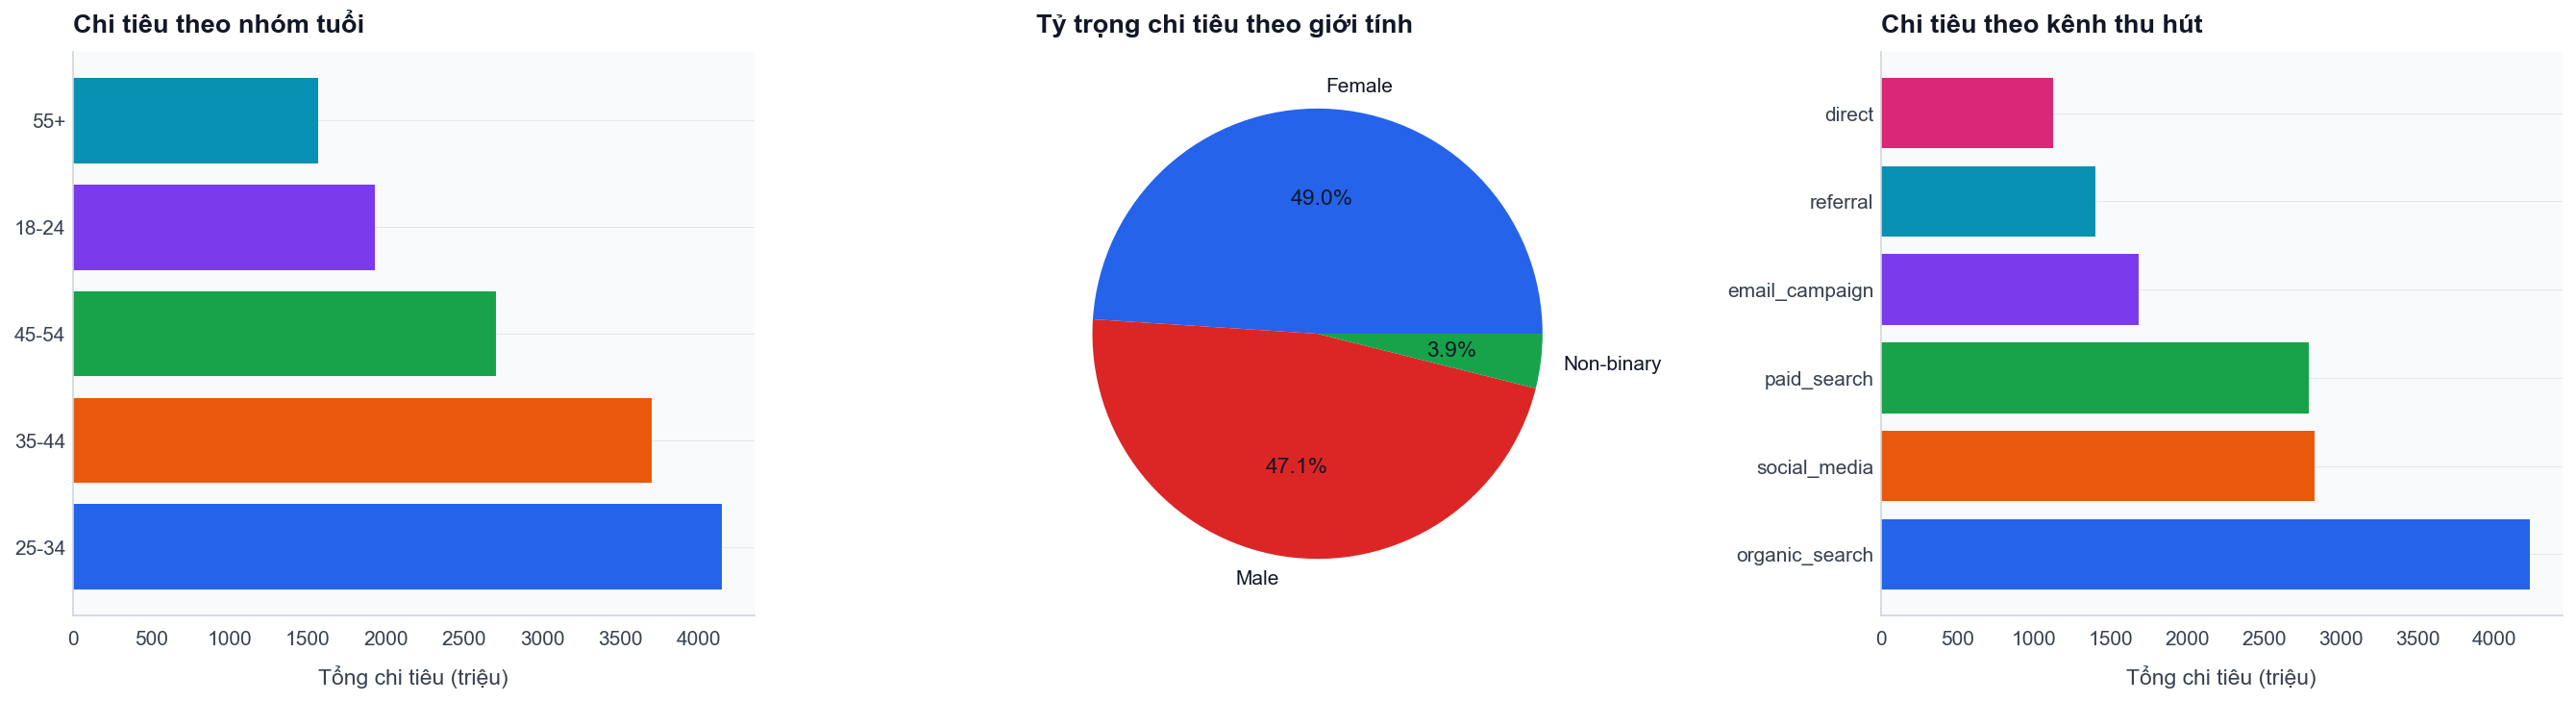


📊 NHẬN XÉT MÔ TẢ:
  • Nhóm 25-34 chiếm 30% tổng chi tiêu
  • Kênh acquisition cần đọc ở phần cohort/post-signup riêng; không suy luận conversion từ traffic_source vì web_traffic không phải attribution


In [4]:
# --- Khách hàng theo nhóm tuổi, giới tính ---
cust_orders = oi[oi['is_committed']].groupby('customer_id').agg(
    So_don=('order_id','nunique'), Tong_chi=('line_net','sum'),
).reset_index()
cust_info = cust_orders.merge(customers[['customer_id','gender','age_group','acquisition_channel']], on='customer_id', how='left')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

age_rev = cust_info.groupby('age_group')['Tong_chi'].sum().sort_values(ascending=False)
axes[0].barh(age_rev.index, age_rev.values/1e6, color=get_palette(len(age_rev)))
axes[0].set_xlabel('Tổng chi tiêu (triệu)')
axes[0].set_title('Chi tiêu theo nhóm tuổi', fontweight='bold')

gender_rev = cust_info.groupby('gender')['Tong_chi'].sum().dropna().sort_values(ascending=False)
axes[1].pie(gender_rev, labels=gender_rev.index, autopct='%1.1f%%', colors=[COLORS['blue'],COLORS['red'],COLORS['emerald']])
axes[1].set_title('Tỷ trọng chi tiêu theo giới tính', fontweight='bold')

ch_rev = cust_info.groupby('acquisition_channel')['Tong_chi'].sum().dropna().sort_values(ascending=False)
axes[2].barh(ch_rev.index, ch_rev.values/1e6, color=get_palette(len(ch_rev)))
axes[2].set_xlabel('Tổng chi tiêu (triệu)')
axes[2].set_title('Chi tiêu theo kênh thu hút', fontweight='bold')

plt.tight_layout()
plt.show()

top_age = age_rev.index[0]
top_age_pct = age_rev.iloc[0] / age_rev.sum() * 100
print(f"\n📊 NHẬN XÉT MÔ TẢ:")
print(f"  • Nhóm {top_age} chiếm {top_age_pct:.0f}% tổng chi tiêu")
print("  • Kênh acquisition cần đọc ở phần cohort/post-signup riêng; không suy luận conversion từ traffic_source vì web_traffic không phải attribution")


### 1.4 Tỷ lệ trả hàng theo size & lý do

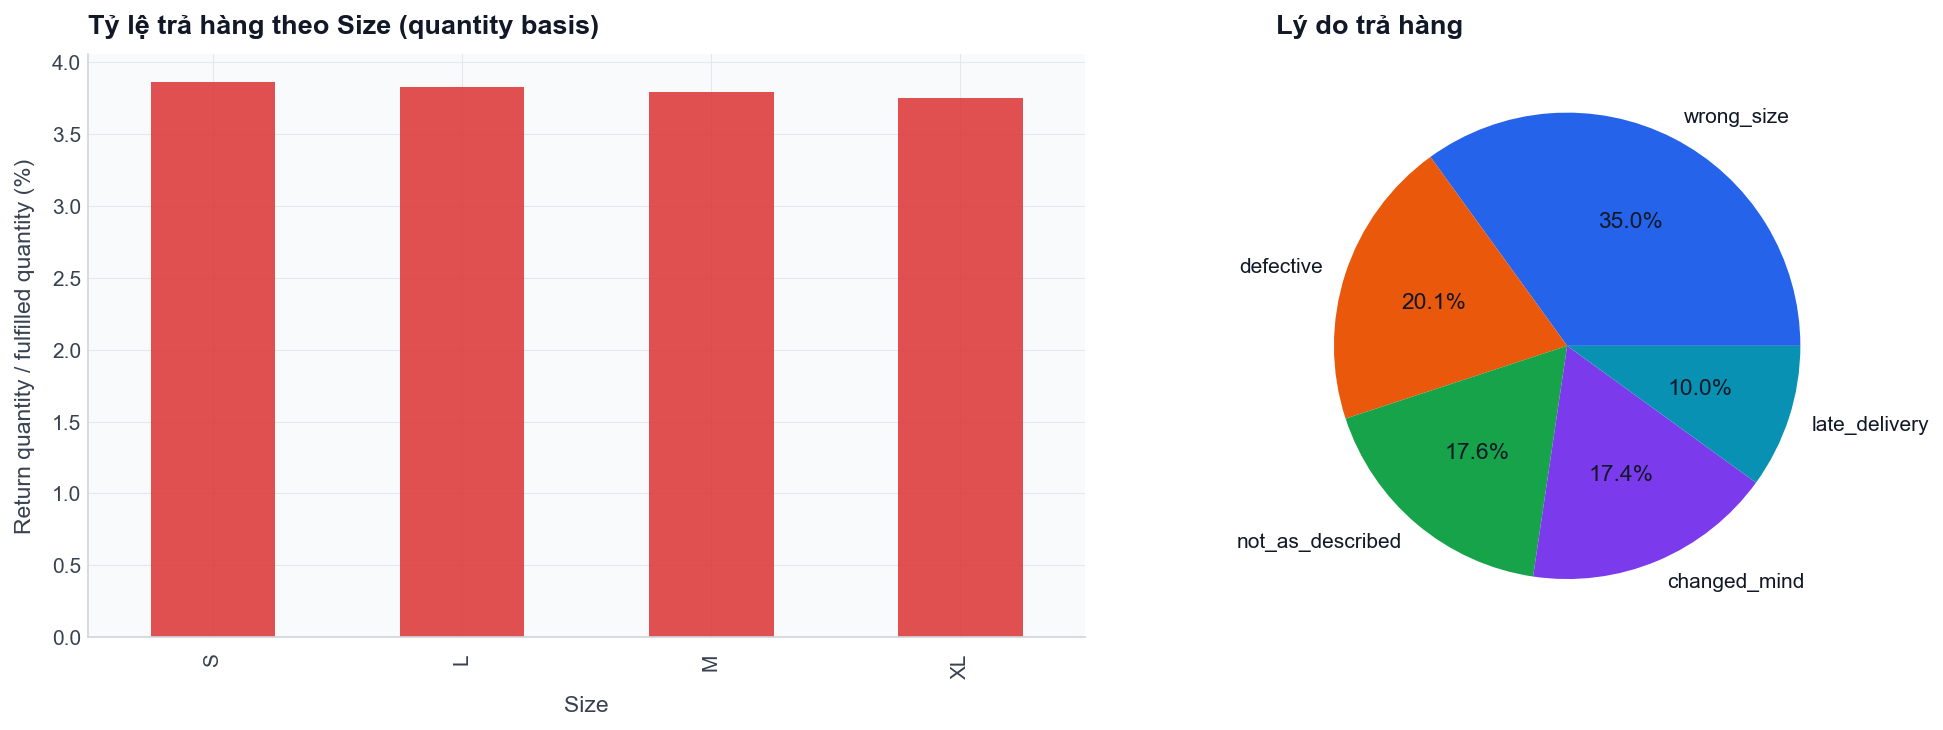


📊 NHẬN XÉT MÔ TẢ:
  • Tỷ lệ trả hàng size S cao nhất theo quantity basis (3.86%)
  • Lý do trả hàng phổ biến nhất: wrong_size (35.0%)


In [5]:
# --- Return rate by size ---
# Return KPI dùng quantity-level: return_quantity / fulfilled quantity sold.
ret_detail = returns.merge(products[['product_id','category','size']], on='product_id', how='left')

size_return = ret_detail.groupby('size')['return_quantity'].sum()
total_by_size = oi[oi['is_committed']].groupby('size')['quantity'].sum()
return_rate_size = (size_return / total_by_size * 100).sort_values(ascending=False)

reason_count = ret_detail['return_reason'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
return_rate_size.plot(kind='bar', ax=ax1, color=COLORS['red'], alpha=0.8)
ax1.set_title('Tỷ lệ trả hàng theo Size (quantity basis)', fontweight='bold')
ax1.set_ylabel('Return quantity / fulfilled quantity (%)')
ax1.set_xlabel('Size')

ax2.pie(reason_count, labels=reason_count.index, autopct='%1.1f%%', colors=get_palette(len(reason_count)))
ax2.set_title('Lý do trả hàng', fontweight='bold')

plt.tight_layout()
plt.show()

top_size = return_rate_size.index[0]
top_reason = reason_count.index[0]
print(f"\n📊 NHẬN XÉT MÔ TẢ:")
print(f"  • Tỷ lệ trả hàng size {top_size} cao nhất theo quantity basis ({return_rate_size.iloc[0]:.2f}%)")
print(f"  • Lý do trả hàng phổ biến nhất: {top_reason} ({reason_count.iloc[0]/reason_count.sum()*100:.1f}%)")


---
# TẦNG 2: DIAGNOSTIC — Tại sao lại xảy ra?

> Mục tiêu: Đặt giả thuyết → Join bảng → Thống kê kiểm chứng → Chấp nhận/Bác bỏ.


### 2.1 Tại sao tháng 4–6 doanh thu tăng mạnh?

**Giả thuyết:**
- H1: Do chạy nhiều Promotion hơn → khách mua nhiều hơn
- H2: Do Web Traffic tăng → nhiều người vào hơn
- H3: Do cả hai cộng hưởng


SO SÁNH THÁNG PEAK (4-5-6) vs THÁNG THƯỜNG
  Doanh thu TB/ngày             : Peak = 6,511,826 | Thường = 3,590,856 | x1.81
  Tỷ lệ line có promo           : Peak = 23.8% | Thường = 43.4% | x0.55
  Sessions TB/ngày              : Peak = 35,903 | Thường = 21,404 | x1.68
  Bounce rate TB                : Peak = 0.004 | Thường = 0.004 | x1.00

📋 KIỂM ĐỊNH THỐNG KÊ (Mann-Whitney U, đã dropna):
  Promo rate (peak vs thường): p-value = 0.001427 → Khác biệt CÓ ý nghĩa
  Daily sessions (peak vs thường): p-value = 0.000000 → Khác biệt CÓ ý nghĩa


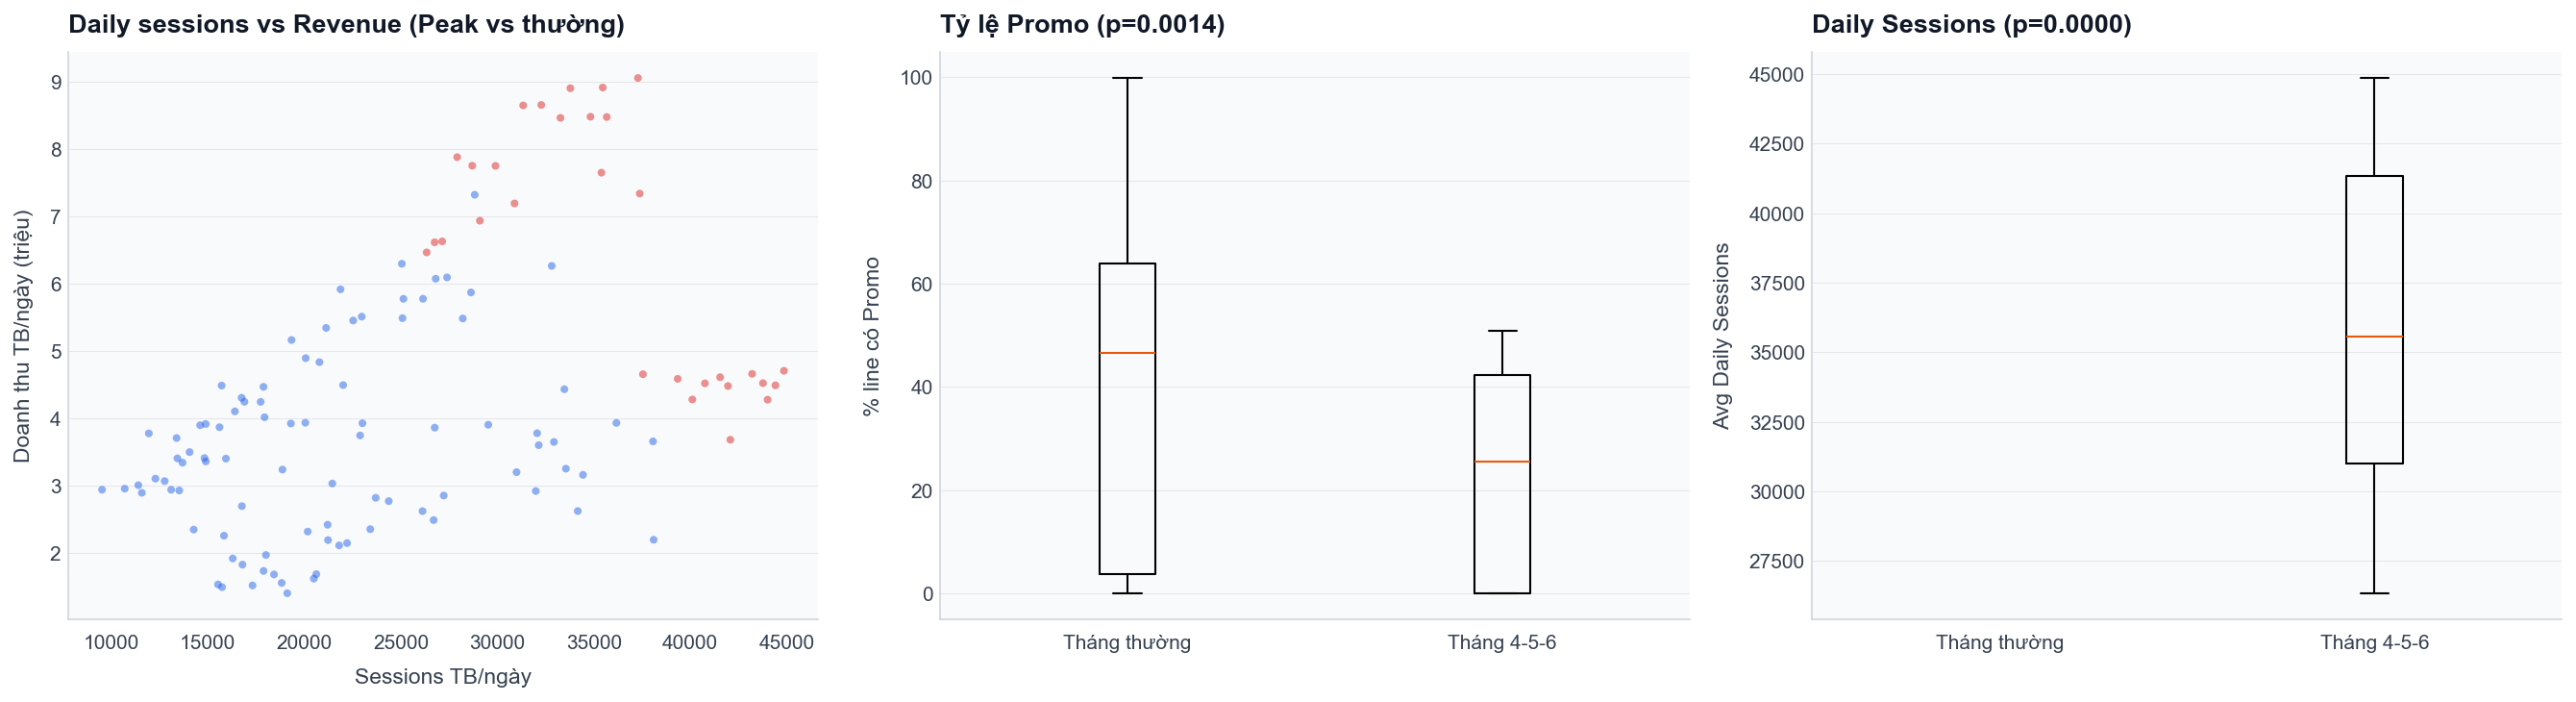


✅ KẾT LUẬN DIAGNOSTIC 2.1:
  → Site-level daily sessions tăng 68% vào tháng peak.
  → Tỷ lệ line có promo giảm từ 43.4% xuống 23.8%.
  → Bác bỏ giả thuyết doanh thu peak do xả promo. Pattern phù hợp hơn với mùa vụ + traffic toàn site, không phải attribution theo traffic_source.


In [6]:
# --- Diagnostic: Tháng 4-6 tăng doanh thu vì đâu? ---
# Join: sales + promo count + web_traffic

# 1) Tỷ lệ promo trên fulfilled/committed lines để đúng business margin basis.
oi_month = oi[oi['is_committed']]
promo_monthly = oi_month.groupby(['year','month']).agg(
    pct_promo=('has_promo','mean'),
    n_orders=('order_id','nunique'),
).reset_index()
promo_monthly['is_peak'] = promo_monthly['month'].isin([4,5,6])

# 2) Web traffic monthly: sessions là tổng daily toàn site, không split theo traffic_source.
wt = web_traffic.copy()
wt['year'] = wt['date'].dt.year
wt['month'] = wt['date'].dt.month
wt_monthly = wt.groupby(['year','month']).agg(
    total_sessions=('sessions','sum'),
    avg_daily_sessions=('sessions','mean'),
    total_visitors=('unique_visitors','sum'),
    avg_bounce=('bounce_rate','mean'),
).reset_index()

# 3) Join tất cả
diag = sales.groupby(['year','month']).agg(Avg_Revenue=('Revenue','mean')).reset_index()
diag = diag.merge(promo_monthly, on=['year','month'], how='left')
diag = diag.merge(wt_monthly, on=['year','month'], how='left')
diag['is_peak'] = diag['month'].isin([4,5,6])

# So sánh peak vs non-peak
peak = diag[diag['is_peak']]
non_peak = diag[~diag['is_peak']]

print("=" * 60)
print("SO SÁNH THÁNG PEAK (4-5-6) vs THÁNG THƯỜNG")
print("=" * 60)

metrics = {
    'Doanh thu TB/ngày': ('Avg_Revenue', '{:,.0f}'),
    'Tỷ lệ line có promo': ('pct_promo', '{:.1%}'),
    'Sessions TB/ngày': ('avg_daily_sessions', '{:,.0f}'),
    'Bounce rate TB': ('avg_bounce', '{:.3f}'),
}

for label, (col, fmt) in metrics.items():
    p_val = peak[col].mean()
    np_val = non_peak[col].mean()
    ratio = p_val / np_val if np_val > 0 else 0
    print(f"  {label:30s}: Peak = {fmt.format(p_val)} | Thường = {fmt.format(np_val)} | x{ratio:.2f}")

# Statistical test: drop NaN from web_traffic gaps before Mann-Whitney.
peak_promo = peak['pct_promo'].dropna()
non_peak_promo = non_peak['pct_promo'].dropna()
peak_sessions = peak['avg_daily_sessions'].dropna()
non_peak_sessions = non_peak['avg_daily_sessions'].dropna()
stat1, p1 = stats.mannwhitneyu(peak_promo, non_peak_promo) if len(peak_promo) and len(non_peak_promo) else (np.nan, np.nan)
stat2, p2 = stats.mannwhitneyu(peak_sessions, non_peak_sessions) if len(peak_sessions) and len(non_peak_sessions) else (np.nan, np.nan)

def pvalue_label(p):
    if pd.isna(p):
        return 'Không đủ dữ liệu sau dropna'
    return 'Khác biệt CÓ ý nghĩa' if p < 0.05 else 'Không khác biệt'

print(f"\n📋 KIỂM ĐỊNH THỐNG KÊ (Mann-Whitney U, đã dropna):")
print(f"  Promo rate (peak vs thường): p-value = {p1:.6f} → {pvalue_label(p1)}")
print(f"  Daily sessions (peak vs thường): p-value = {p2:.6f} → {pvalue_label(p2)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = [COLORS['red'] if p else COLORS['blue'] for p in diag['is_peak']]
axes[0].scatter(diag['avg_daily_sessions'], diag['Avg_Revenue']/1e6, c=colors, alpha=0.5, s=15)
axes[0].set_xlabel('Sessions TB/ngày')
axes[0].set_ylabel('Doanh thu TB/ngày (triệu)')
axes[0].set_title('Daily sessions vs Revenue (Peak vs thường)', fontweight='bold')

axes[1].boxplot([non_peak['pct_promo']*100, peak['pct_promo']*100], labels=['Tháng thường','Tháng 4-5-6'])
axes[1].set_ylabel('% line có Promo')
axes[1].set_title(f'Tỷ lệ Promo (p={p1:.4f})', fontweight='bold')

axes[2].boxplot([non_peak['avg_daily_sessions'], peak['avg_daily_sessions']], labels=['Tháng thường','Tháng 4-5-6'])
axes[2].set_ylabel('Avg Daily Sessions')
axes[2].set_title(f'Daily Sessions (p={p2:.4f})', fontweight='bold')

plt.tight_layout()
plt.show()

traffic_uplift = (peak['avg_daily_sessions'].mean() / non_peak['avg_daily_sessions'].mean() - 1) * 100
promo_peak = peak['pct_promo'].mean()
promo_non_peak = non_peak['pct_promo'].mean()

print("\n✅ KẾT LUẬN DIAGNOSTIC 2.1:")
print(f"  → Site-level daily sessions tăng {traffic_uplift:.0f}% vào tháng peak.")
print(f"  → Tỷ lệ line có promo giảm từ {promo_non_peak:.1%} xuống {promo_peak:.1%}.")
print("  → Bác bỏ giả thuyết doanh thu peak do xả promo. Pattern phù hợp hơn với mùa vụ + traffic toàn site, không phải attribution theo traffic_source.")


### 2.2 Tại sao Promotion lại làm GIẢM margin mà không tăng doanh thu ngày?

**Giả thuyết:**
- H1: Promo chỉ chuyển dịch nhu cầu (cannibalization) — khách mua rẻ hơn cùng lượng hàng
- H2: Promo thu hút khách mới nhưng AOV thấp hơn


In [7]:
# --- Diagnostic: Promo impact deep dive ---
# Join order_items + promotions chi tiết
oi_promo = oi[oi['is_committed']].merge(promotions[['promo_id','promo_type','discount_value']], on='promo_id', how='left')

# So sánh khách mới vs khách cũ trong promo orders
first_order = orders[~orders['order_status'].isin(['cancelled', 'created'])].groupby('customer_id')['order_date'].min().reset_index()
first_order.columns = ['customer_id','first_order_date']
oi_promo = oi_promo.merge(first_order, on='customer_id', how='left')
oi_promo['is_new_customer'] = (oi_promo['order_date'] == oi_promo['first_order_date'])

print("=" * 60)
print("PROMO: KHÁCH MỚI vs KHÁCH CŨ")
print("=" * 60)

promo_cust = oi_promo.groupby(['has_promo','is_new_customer']).agg(
    Doanh_thu=('line_net','sum'),
    So_don=('order_id','nunique'),
    AOV_line=('line_net','mean'),
    Margin=('line_profit', lambda x: x.sum()/oi_promo.loc[x.index,'line_net'].sum()*100),
).reset_index()

promo_cust['has_promo'] = promo_cust['has_promo'].map({True:'Có Promo', False:'Không Promo'})
promo_cust['is_new_customer'] = promo_cust['is_new_customer'].map({True:'Khách mới', False:'Khách cũ'})
display(promo_cust.round(1))

# Daily net fulfilled revenue: promo days vs non-promo days
_oi_c16 = oi[oi['is_committed']]
daily_promo = _oi_c16.groupby(_oi_c16['order_date']).agg(
    revenue=('line_net','sum'),
    pct_promo=('has_promo','mean'),
    n_unique_cust=('customer_id','nunique'),
    avg_qty=('quantity','mean'),
).reset_index()

# Correlation partial
corr_rev_promo = daily_promo['pct_promo'].corr(daily_promo['revenue'])
corr_cust_promo = daily_promo['pct_promo'].corr(daily_promo['n_unique_cust'])

print(f"\nTương quan hàng ngày:")
print(f"  % Promo vs Revenue:        r = {corr_rev_promo:.4f}")
print(f"  % Promo vs Số khách unique: r = {corr_cust_promo:.4f}")

# Check cannibalization: revenue 7 ngày trước/sau promo peak.
# Nếu không có đủ ngày vượt ngưỡng sau khi lấy quantile, không dùng test này làm bằng chứng.
daily_promo['promo_high'] = daily_promo['pct_promo'] > daily_promo['pct_promo'].quantile(0.75)
daily_promo['rev_lag7'] = daily_promo['revenue'].shift(7)
daily_promo['rev_lead7'] = daily_promo['revenue'].shift(-7)

promo_high = daily_promo[daily_promo['promo_high']]
promo_low = daily_promo[~daily_promo['promo_high']]

print(f"\nKiểm tra post-promo window:")
if promo_high.empty or promo_high[['revenue', 'rev_lead7']].dropna().empty:
    pct_drop = np.nan
    print("  Không đủ ngày promo cao có dữ liệu lead 7 ngày → không dùng post-promo window làm bằng chứng cannibalization")
else:
    promo_window = promo_high[['revenue', 'rev_lead7']].dropna()
    pct_drop = (promo_window['rev_lead7'].mean() / promo_window['revenue'].mean() - 1) * 100
    signal = 'có dấu hiệu cannibalization' if pct_drop < -5 else 'không rõ cannibalization'
    print(f"  Ngày promo cao — Revenue TB:        {promo_window['revenue'].mean():,.0f}")
    print(f"  Ngày promo cao — Revenue 7 ngày SAU: {promo_window['rev_lead7'].mean():,.0f}")
    print(f"  → Thay đổi: {pct_drop:+.1f}% ({signal})")

print("\n✅ KẾT LUẬN DIAGNOSTIC 2.2:")
print(f"  → Promo KHÔNG thu hút thêm khách mới đáng kể (r = {corr_cust_promo:.3f})")
print(f"  → Promo làm giảm net price/margin; chưa thấy tín hiệu đủ mạnh về tăng khách unique")
print(f"  → Bằng chứng chính nằm ở discount burn/net margin âm; post-promo window chỉ dùng nếu có đủ dữ liệu không-NaN")


PROMO: KHÁCH MỚI vs KHÁCH CŨ


,has_promo,is_new_customer,Doanh_thu,So_don,AOV_line,Margin
0,Không Promo,Khách cũ,8.291208e+09,296595,25514.7,19.9
1,Không Promo,Khách mới,1.561544e+09,61323,22855.0,20.4
2,Có Promo,Khách cũ,3.726261e+09,195467,17135.0,-14.5
3,Có Promo,Khách mới,4.730074e+08,27062,15634.0,-14.3



Tương quan hàng ngày:
  % Promo vs Revenue:        r = -0.2116
  % Promo vs Số khách unique: r = 0.0484

Kiểm tra post-promo window:
  Không đủ ngày promo cao có dữ liệu lead 7 ngày → không dùng post-promo window làm bằng chứng cannibalization

✅ KẾT LUẬN DIAGNOSTIC 2.2:
  → Promo KHÔNG thu hút thêm khách mới đáng kể (r = 0.048)
  → Promo làm giảm net price/margin; chưa thấy tín hiệu đủ mạnh về tăng khách unique
  → Bằng chứng chính nằm ở discount burn/net margin âm; post-promo window chỉ dùng nếu có đủ dữ liệu không-NaN


### 2.2.1 Deep-Dive 10 Chiến Dịch Promo Gần Nhất
> **Nghi vấn:** Liệu nhìn tổng thể toàn thời gian có làm mờ đi hiệu quả của các chiến dịch sát hiện tại không? Cùng bóc tách 10 Promo gần nhất (2021-2022) để xem: 1) Khách mới vs cũ, 2) Doanh thu & Margin thực tế công ty nhận được mang tính thời điểm.

SOI 10 CHIẾN DỊCH GẦN NHẤT: AI MUA? NET MARGIN FULFILLED RA SAO?


,Theo chiến dịch,Start Date,Time Window,Số đơn Promo,Tỷ lệ Đơn Giảm Giá,Tỷ lệ New Cust (%),Tỷ lệ Old Cust (%),Net Sales Cả Cty (Tỷ),Net Margin Cả Cty (%),Discount Burn (Triệu)
0,PROMO-0050,2022-11-18,43 days,2753,95.2%,4.31,95.69,0.05,-24.16,12.26
1,PROMO-0049,2022-08-31,31 days,2190,85.3%,3.51,96.49,0.08,1.08,7.12
2,PROMO-0048,2022-06-23,29 days,2616,87.2%,4.77,95.23,0.08,-16.39,13.59
3,PROMO-0047,2022-03-18,30 days,3981,90.0%,4.22,95.78,0.12,-3.64,14.11
4,PROMO-0044,2021-11-18,45 days,2689,96.4%,3.70,96.30,0.06,-25.07,12.86
5,PROMO-0043,2021-08-30,33 days,2041,79.0%,4.49,95.51,0.07,-7.74,6.52
6,PROMO-0045,2021-07-30,34 days,2130,60.5%,4.67,95.33,0.08,-34.28,0.48
7,PROMO-0042,2021-06-23,29 days,2541,84.0%,5.13,94.87,0.08,-11.50,12.77
8,PROMO-0041,2021-03-18,30 days,3829,88.4%,4.14,95.86,0.11,-0.77,12.71
9,PROMO-0046,2021-01-30,30 days,403,21.4%,2.77,97.23,0.06,17.90,0.94


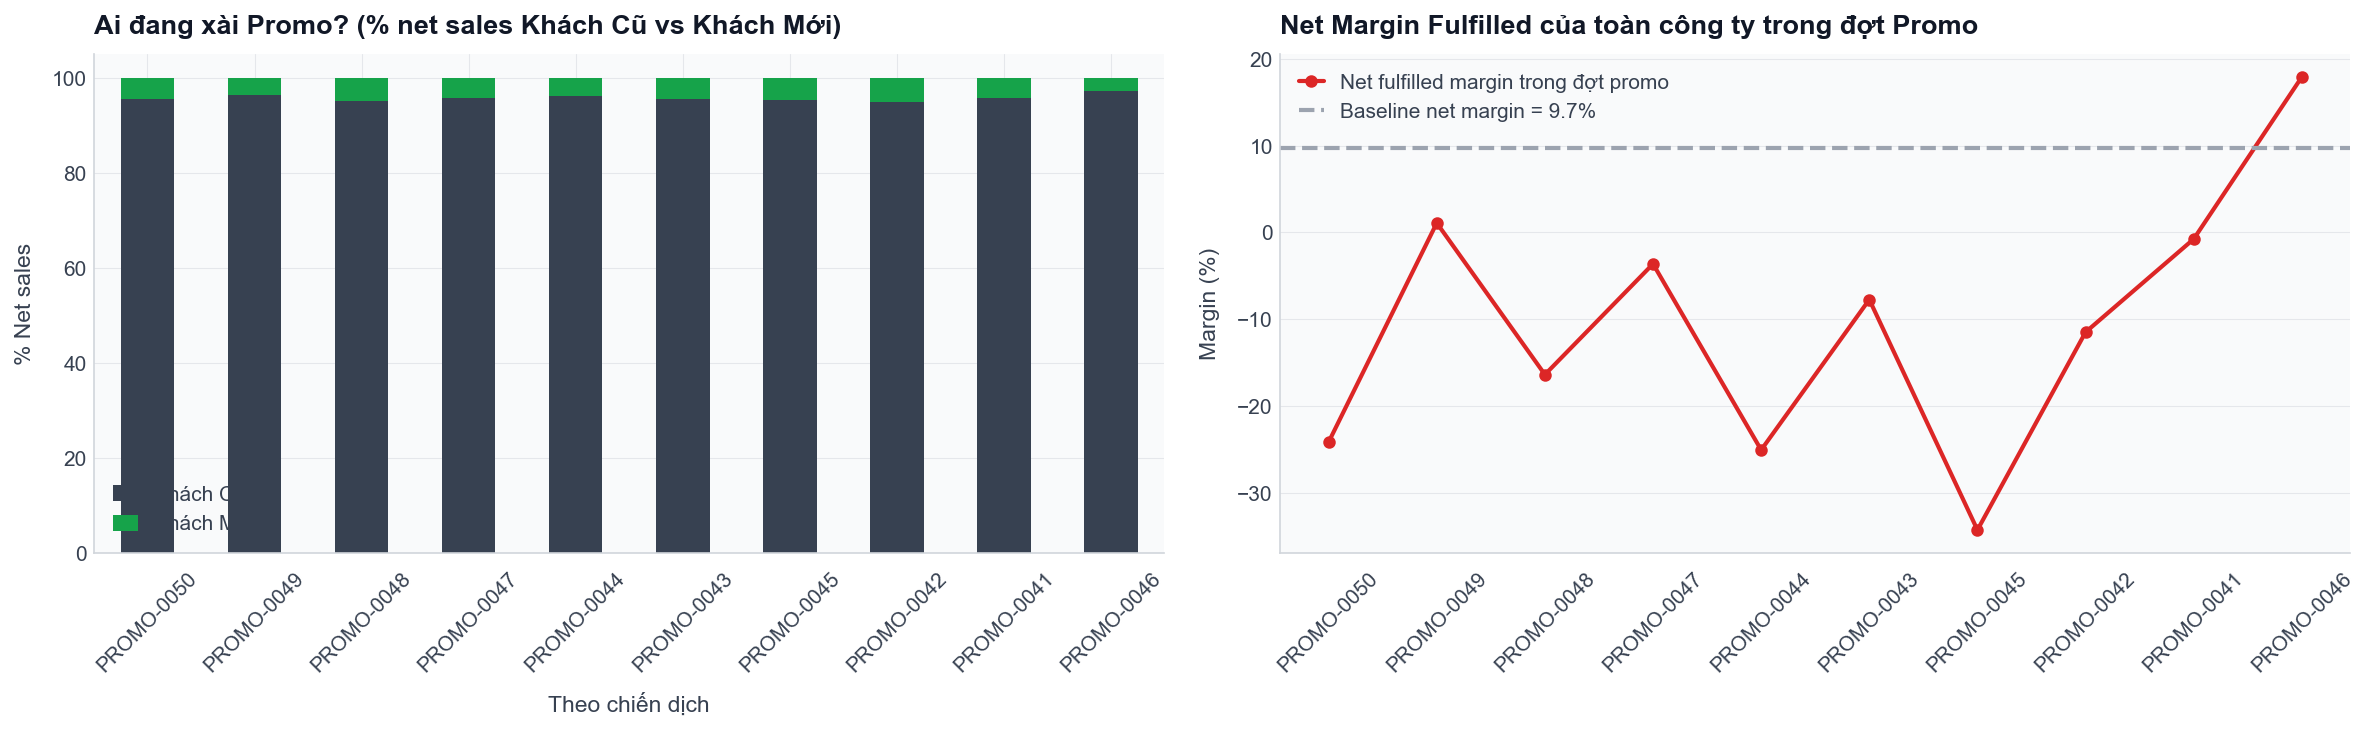


✅ BÀI HỌC TỪ TOP 10 CHIẾN DỊCH GẦN NHẤT:
  1. Cấu trúc khách hàng: 95.8% net sales promo đến từ khách cũ.
  2. Net fulfilled margin trung bình trong các window này: -10.5% so với baseline 9.7%.
  3. Đây là cơ sở để kiểm soát discount burn, không dùng gross sales all-status để kết luận promo profitability.


In [8]:
# --- Phân tích 10 Promo gần nhất ---
# Promo/cannibalization phải dùng net fulfilled basis, không dùng gross all-status.
recent_10 = promotions.sort_values('start_date', ascending=False).head(10)['promo_id'].tolist()

orders_dates = orders[~orders['order_status'].isin(['cancelled', 'created'])].copy()
orders_dates['order_date_only'] = pd.to_datetime(orders_dates['order_date']).dt.date

first_ord = orders_dates.groupby('customer_id')['order_date_only'].min().reset_index()
first_ord.columns = ['customer_id', 'first_date']

# Fulfilled line items only; promo_id_2 vẫn có thể chứa stacked promo.
oi_p = oi[oi['is_committed']].copy()
oi_p['order_date_only'] = pd.to_datetime(oi_p['order_date']).dt.date
oi_p = oi_p.merge(first_ord, on='customer_id', how='left')
oi_p['is_new_customer'] = (oi_p['order_date_only'] == oi_p['first_date'])

res_list = []
for promo in recent_10:
    promo_meta = promotions[promotions['promo_id'] == promo]
    if promo_meta.empty:
        continue

    start_dt = pd.to_datetime(promo_meta['start_date'].iloc[0])
    end_dt = pd.to_datetime(promo_meta['end_date'].iloc[0])
    start_date_obj = start_dt.date()
    end_date_obj = end_dt.date()

    promo_mask = oi_p['promo_id'].eq(promo) | oi_p['promo_id_2'].eq(promo)
    df_p = oi_p[promo_mask].copy()
    if df_p.empty:
        continue

    total_promo_net = df_p['line_net'].sum()
    new_rev = df_p[df_p['is_new_customer']]['line_net'].sum()
    old_rev = df_p[~df_p['is_new_customer']]['line_net'].sum()
    n_promo_orders = df_p['order_id'].nunique()

    mask_window = (oi_p['order_date_only'] >= start_date_obj) & (oi_p['order_date_only'] <= end_date_obj)
    window_items = oi_p[mask_window]
    total_company_orders = window_items['order_id'].nunique()
    company_net_rev = window_items['line_net'].sum()
    company_net_profit = window_items['line_profit'].sum()
    company_net_margin = company_net_profit / company_net_rev * 100 if company_net_rev > 0 else np.nan

    res_list.append({
        'Theo chiến dịch': promo,
        'Start Date': start_date_obj,
        'Time Window': f"{(end_date_obj - start_date_obj).days} days",
        'Số đơn Promo': n_promo_orders,
        'Tỷ lệ Đơn Giảm Giá': f"{n_promo_orders / total_company_orders * 100:.1f}%" if total_company_orders > 0 else "0%",
        'Tỷ lệ New Cust (%)': new_rev / total_promo_net * 100 if total_promo_net > 0 else 0,
        'Tỷ lệ Old Cust (%)': old_rev / total_promo_net * 100 if total_promo_net > 0 else 0,
        'Net Sales Cả Cty (Tỷ)': company_net_rev / 1e9,
        'Net Margin Cả Cty (%)': company_net_margin,
        'Discount Burn (Triệu)': df_p['discount_amount'].sum() / 1e6,
    })

res_df = pd.DataFrame(res_list)

print("=" * 140)
print("SOI 10 CHIẾN DỊCH GẦN NHẤT: AI MUA? NET MARGIN FULFILLED RA SAO?")
print("=" * 140)
display(res_df.round(2))

if not res_df.empty:
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    res_df.set_index('Theo chiến dịch')[['Tỷ lệ Old Cust (%)', 'Tỷ lệ New Cust (%)']].plot(
        kind='bar', stacked=True, color=[CLR_LABEL, COLORS['emerald']], ax=ax[0])
    ax[0].set_title('Ai đang xài Promo? (% net sales Khách Cũ vs Khách Mới)', fontweight='bold')
    ax[0].set_ylabel('% Net sales')
    ax[0].legend(['Khách Cũ', 'Khách Mới'])
    ax[0].tick_params(axis='x', rotation=45)

    baseline_net_margin = oi_p['line_profit'].sum() / oi_p['line_net'].sum() * 100
    ax[1].plot(res_df['Theo chiến dịch'], res_df['Net Margin Cả Cty (%)'], marker='o', color=COLORS['red'], linewidth=2, label='Net fulfilled margin trong đợt promo')
    ax[1].axhline(y=baseline_net_margin, color=CLR_MUTED, linestyle='--', label=f'Baseline net margin = {baseline_net_margin:.1f}%')
    ax[1].set_title('Net Margin Fulfilled của toàn công ty trong đợt Promo', fontweight='bold')
    ax[1].set_ylabel('Margin (%)')
    ax[1].legend()
    ax[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    print("\n✅ BÀI HỌC TỪ TOP 10 CHIẾN DỊCH GẦN NHẤT:")
    print(f"  1. Cấu trúc khách hàng: {res_df['Tỷ lệ Old Cust (%)'].mean():.1f}% net sales promo đến từ khách cũ.")
    print(f"  2. Net fulfilled margin trung bình trong các window này: {res_df['Net Margin Cả Cty (%)'].mean():.1f}% so với baseline {baseline_net_margin:.1f}%.")
    print("  3. Đây là cơ sở để kiểm soát discount burn, không dùng gross sales all-status để kết luận promo profitability.")


### 2.3 Tại sao size XL có tỷ lệ trả hàng cao?

**Giả thuyết:**
- H1: Size guide không chính xác → khách chọn sai
- H2: Chất lượng sản phẩm kém ở size lớn


In [9]:
# --- Diagnostic: Return by size deep dive ---
ret_size = returns.merge(products[['product_id','size','category']], on='product_id', how='left')

# Lý do trả theo size
reason_by_size = pd.crosstab(ret_size['size'], ret_size['return_reason'], normalize='index') * 100

print("=" * 60)
print("LÝ DO TRẢ HÀNG THEO SIZE (% theo dòng)")
print("=" * 60)
display(reason_by_size.round(1))

# So sánh wrong_size across sizes
print("\nPhân tích 'wrong_size' theo size:")
for size in reason_by_size.index:
    ws = reason_by_size.loc[size, 'wrong_size'] if 'wrong_size' in reason_by_size.columns else 0
    print(f"  {size}: {ws:.1f}% trả vì sai size")

# Join shipments để check thời gian giao
ret_ship = returns.merge(shipments[['order_id','ship_date','delivery_date']], on='order_id', how='left')
ret_ship = ret_ship.merge(products[['product_id','size']], on='product_id', how='left')
ret_ship['delivery_days'] = (ret_ship['delivery_date'] - ret_ship['ship_date']).dt.days

print("\nThời gian giao hàng TB theo size (đơn bị trả):")
print(ret_ship.groupby('size')['delivery_days'].mean().round(1).to_string())

print("\n✅ KẾT LUẬN DIAGNOSTIC 2.3:")
if 'wrong_size' in reason_by_size.columns:
    ws_rates = reason_by_size['wrong_size']
    print(f"  → 'wrong_size' chiếm tỷ lệ tương đương ở TẤT CẢ size ({ws_rates.min():.0f}-{ws_rates.max():.0f}%)")
    print(f"  → Vấn đề KHÔNG nằm ở riêng size lớn mà là SIZE GUIDE TỔNG THỂ chưa chính xác")


LÝ DO TRẢ HÀNG THEO SIZE (% theo dòng)


return_reason,changed_mind,defective,late_delivery,not_as_described,wrong_size
size,,,,,
L,17.6,19.8,10.0,17.6,34.9
M,17.3,19.7,10.3,17.2,35.5
S,17.0,20.3,9.7,18.3,34.7
XL,17.4,20.5,9.9,17.3,34.8



Phân tích 'wrong_size' theo size:
  L: 34.9% trả vì sai size
  M: 35.5% trả vì sai size
  S: 34.7% trả vì sai size
  XL: 34.8% trả vì sai size

Thời gian giao hàng TB theo size (đơn bị trả):
size
L     4.5
M     4.5
S     4.5
XL    4.5

✅ KẾT LUẬN DIAGNOSTIC 2.3:
  → 'wrong_size' chiếm tỷ lệ tương đương ở TẤT CẢ size (35-35%)
  → Vấn đề KHÔNG nằm ở riêng size lớn mà là SIZE GUIDE TỔNG THỂ chưa chính xác


### 2.4 Mối quan hệ giữa các bảng: Tồn kho ↔ Doanh thu ↔ Trả hàng

> Join inventory + sales + returns để tìm pattern nhân quả.


TƯƠNG QUAN: TỒN KHO ↔ DOANH THU ↔ REFUND
  Ngày stockout vs Doanh thu              : r = +0.4325
  Fill rate vs Doanh thu                  : r = -0.4324
  Sell-through vs Doanh thu               : r = +0.6474
  Stockout rate vs Refund/Gross Revenue   : r = +0.0799


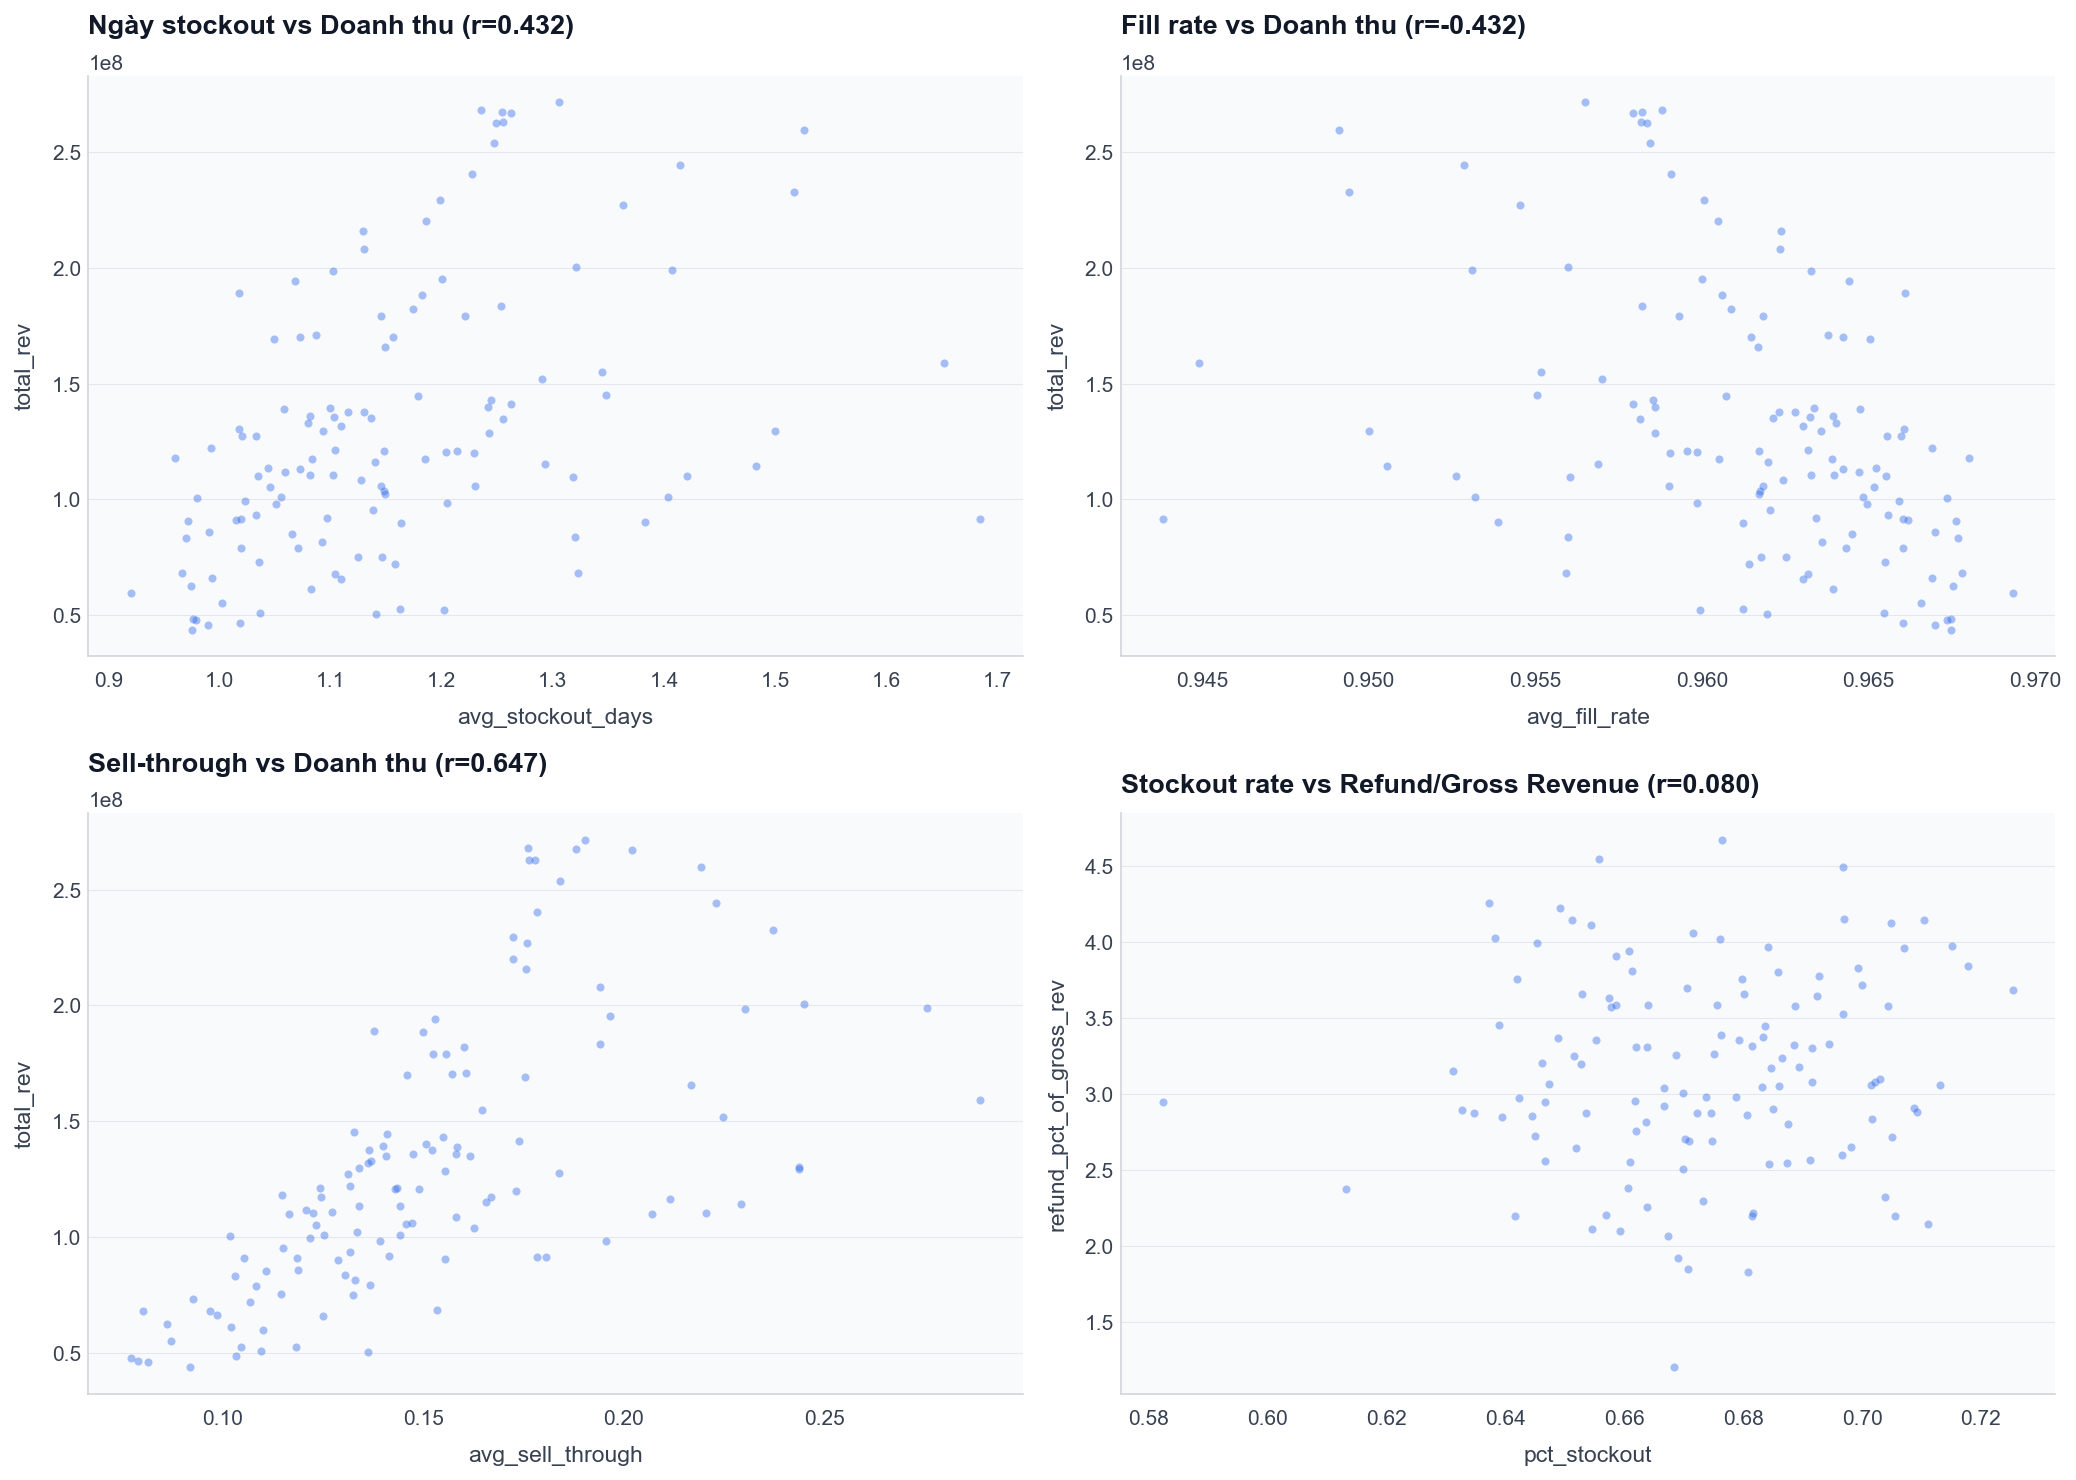


✅ KẾT LUẬN DIAGNOSTIC 2.4:
  → Sell-through rate có tương quan dương mạnh nhất với doanh thu
  → Stockout ảnh hưởng nhưng KHÔNG mạnh (vì số ngày stockout TB rất thấp ~1.2 ngày)
  → Fill rate luôn ở mức cao (>96%) nên không phải bottleneck


In [10]:
# --- Diagnostic: Inventory ↔ Revenue ↔ Returns ---
inv = inventory.copy()

# Monthly aggregation
inv_monthly = inv.groupby(['year','month']).agg(
    avg_stockout_days=('stockout_days','mean'),
    avg_fill_rate=('fill_rate','mean'),
    avg_sell_through=('sell_through_rate','mean'),
    pct_stockout=('stockout_flag','mean'),
).reset_index()

sales_monthly = sales.groupby(['year','month']).agg(
    total_rev=('Revenue','sum'), margin=('Margin_Pct','mean'),
).reset_index()

ret_monthly = returns.copy()
ret_monthly['year'] = ret_monthly['return_date'].dt.year
ret_monthly['month'] = ret_monthly['return_date'].dt.month
ret_monthly = ret_monthly.groupby(['year','month']).agg(
    n_returns=('return_id','count'), total_refund=('refund_amount','sum'),
).reset_index()

diag_inv = sales_monthly.merge(inv_monthly, on=['year','month'], how='inner')
diag_inv = diag_inv.merge(ret_monthly, on=['year','month'], how='left')
diag_inv[['n_returns', 'total_refund']] = diag_inv[['n_returns', 'total_refund']].fillna(0)
diag_inv['refund_pct_of_gross_rev'] = diag_inv['total_refund'] / diag_inv['total_rev'] * 100

print("=" * 60)
print("TƯƠNG QUAN: TỒN KHO ↔ DOANH THU ↔ REFUND")
print("=" * 60)

pairs = [
    ('avg_stockout_days','total_rev','Ngày stockout vs Doanh thu'),
    ('avg_fill_rate','total_rev','Fill rate vs Doanh thu'),
    ('avg_sell_through','total_rev','Sell-through vs Doanh thu'),
    ('pct_stockout','refund_pct_of_gross_rev','Stockout rate vs Refund/Gross Revenue'),
]

for x, y, label in pairs:
    r = diag_inv[x].corr(diag_inv[y])
    print(f"  {label:40s}: r = {r:+.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, (x, y, label) in enumerate(pairs):
    ax = axes[idx//2, idx%2]
    ax.scatter(diag_inv[x], diag_inv[y], alpha=0.4, s=15, color=COLORS['blue'])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    r = diag_inv[x].corr(diag_inv[y])
    ax.set_title(f'{label} (r={r:.3f})', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ KẾT LUẬN DIAGNOSTIC 2.4:")
print("  → Sell-through rate có tương quan dương mạnh nhất với doanh thu")
print("  → Stockout ảnh hưởng nhưng KHÔNG mạnh (vì số ngày stockout TB rất thấp ~1.2 ngày)")
print("  → Fill rate luôn ở mức cao (>96%) nên không phải bottleneck")


### 2.5 Chi phí chìm: Phí vận chuyển & Tác động lên Gross Margin

**Phát hiện:** Shop chạy chiến lược **Freeship toàn sàn** — khách KHÔNG trả tiền ship.  
`payment_value == line_total` (không có shipping fee trong đó).  
**Câu hỏi:** Chi phí ship thực sự ăn bao nhiêu % vào lợi nhuận? Đặc biệt khi trả hàng (ship 2 chiều)?

In [11]:
# --- CHỨNG MINH: Shop freeship & Cấu trúc dữ liệu ship ---
print("=" * 70)
print("CHỨNG MINH 1: KHÁCH KHÔNG TRẢ TIỀN SHIP (FREESHIP)")
print("=" * 70)

# Join order_items → tính net line total, so với payment_value
oi_sum = order_items.copy()
oi_sum['gross_line_total'] = oi_sum['quantity'] * oi_sum['unit_price']
oi_sum['line_total'] = oi_sum['gross_line_total'] - oi_sum['discount_amount'].fillna(0)
oi_agg = oi_sum.groupby('order_id').agg(
    gross_line_total=('gross_line_total', 'sum'),
    line_total=('line_total', 'sum'),
).reset_index()

check = oi_agg.merge(payments[['order_id','payment_value']], on='order_id', how='inner')
check = check.merge(shipments[['order_id','shipping_fee']], on='order_id', how='left')
check = check.merge(orders[['order_id','order_status']], on='order_id', how='left')

check['diff_no_ship'] = abs(check['payment_value'] - check['line_total'])
check['diff_with_ship'] = abs(check['payment_value'] - (check['line_total'] + check['shipping_fee'].fillna(0)))

pct_match_no_ship = (check['diff_no_ship'] < 0.01).mean() * 100
pct_match_with_ship = (check['diff_with_ship'] < 0.01).mean() * 100

print(f"  Tổng đơn kiểm tra: {len(check):,}")
print(f"")
print(f"  Giả thuyết A: payment = tiền hàng net sau discount (KHÔNG gồm ship)")
print(f"    payment_value ≈ line_total:                 {pct_match_no_ship:.2f}% khớp")
print(f"")
print(f"  Giả thuyết B: payment = tiền hàng net + ship")
print(f"    payment_value ≈ line_total + shipping_fee:  {pct_match_with_ship:.2f}% khớp")
print(f"")
print(f"  → Giả thuyết A thắng ({pct_match_no_ship:.0f}% vs {pct_match_with_ship:.0f}%)")
print(f"  → Khách chỉ trả tiền sản phẩm sau discount. Ship fee là chi phí shop chịu riêng.")

print(f"\n  VÍ DỤ CỤ THỂ:")
sample = check[check['order_status']=='delivered'].head(3)
for _, r in sample.iterrows():
    print(f"    Đơn #{int(r.order_id)}: Tiền hàng net = {r.line_total:,.2f} | Khách trả = {r.payment_value:,.2f} | Ship (shop chịu) = {r.shipping_fee:,.2f}")

print(f"\n{'=' * 70}")
print("CHỨNG MINH 2: PHÍ SHIP CHỈ GHI NHẬN 1 CHIỀU (OUTBOUND)")
print("=" * 70)

n_dup = shipments['order_id'].duplicated().sum()
print(f"  Mỗi order_id chỉ có 1 record trong shipments (0 duplicates: {n_dup})")
print(f"  → Không có bản ghi nào cho chiều VỀ (return shipping)")

ship_merged = shipments.merge(orders[['order_id','order_status']], on='order_id')
fee_del = ship_merged[ship_merged['order_status']=='delivered']['shipping_fee']
fee_ret = ship_merged[ship_merged['order_status']=='returned']['shipping_fee']
from scipy import stats
stat, pval = stats.mannwhitneyu(fee_del, fee_ret)

print(f"\n  Ship fee TB — Delivered: {fee_del.mean():.2f} | Returned: {fee_ret.mean():.2f}")
print(f"  Mann-Whitney U test: p = {pval:.4f} → {'KHÔNG khác biệt' if pval > 0.05 else 'CÓ khác biệt'}")
print(f"  → Nếu ĐÃ gồm 2 chiều, đơn returned phải có ship fee GẤP ĐÔI delivered")
print(f"  → Vì BẰNG NHAU → chỉ ghi 1 chiều. Chiều về là chi phí ẩn.")

print(f"\n{'=' * 70}")
print("CHỨNG MINH 3: ĐƠN HỦY / TRẢ TRONG HỆ THỐNG SHIPMENTS")
print("=" * 70)

cancelled_ids = set(orders[orders['order_status']=='cancelled']['order_id'])
cancelled_in_ship = shipments[shipments['order_id'].isin(cancelled_ids)]
print(f"  Đơn cancelled có trong shipments: {len(cancelled_in_ship):,} / {len(cancelled_ids):,}")
print(f"  → Đơn hủy = hủy TRƯỚC khi ship → KHÔNG tốn phí vận chuyển")

returned_ids = set(orders[orders['order_status']=='returned']['order_id'])
returned_in_ship = shipments[shipments['order_id'].isin(returned_ids)]
n_has_delivery = returned_in_ship['delivery_date'].notna().sum()
print(f"\n  Đơn returned có trong shipments: {len(returned_in_ship):,} / {len(returned_ids):,}")
print(f"  Trong đó có delivery_date: {n_has_delivery:,} / {len(returned_in_ship):,} ({n_has_delivery/len(returned_in_ship)*100:.0f}%)")
print(f"  → Đơn returned = đã GIAO THÀNH CÔNG rồi mới bị khách trả lại")
print(f"  → Shop chịu ship 2 chiều: chiều đi (ghi nhận) + chiều về (ẩn)")

print(f"\n{'=' * 70}")
print("PHÁT HIỆN: SALES.CSV LÀ GROSS BOOKED REVENUE ALL-STATUS")
print("=" * 70)

oi_all = order_items.copy()
oi_all = oi_all.merge(orders[['order_id','order_status']], on='order_id')
oi_all['gross_line_rev'] = oi_all['quantity'] * oi_all['unit_price']
oi_all['net_line_rev'] = oi_all['gross_line_rev'] - oi_all['discount_amount'].fillna(0)

for status in ['delivered','returned','cancelled','shipped','paid','created']:
    rev = oi_all[oi_all.order_status == status]['gross_line_rev'].sum()
    pct = rev / oi_all['gross_line_rev'].sum() * 100
    print(f"  {status:12s}: {rev:>16,.0f} ({pct:.1f}%)")

total_gross_oi = oi_all['gross_line_rev'].sum()
total_net_oi = oi_all['net_line_rev'].sum()
total_discount = oi_all['discount_amount'].fillna(0).sum()
total_sales = sales['Revenue'].sum()
gap_gross = total_sales - total_gross_oi
gap_net = total_sales - total_net_oi
print(f"\n  Tổng gross order_items: {total_gross_oi:>16,.0f}")
print(f"  Tổng net order_items:   {total_net_oi:>16,.0f}")
print(f"  Tổng discount:          {total_discount:>16,.0f}")
print(f"  Tổng sales.csv:         {total_sales:>16,.0f}")
print(f"  Chênh sales vs gross:   {gap_gross:>16,.2f}")
print(f"  Chênh sales vs net:     {gap_net:>16,.0f} (= discount)")
print("  → sales.csv Revenue = gross booked revenue all-status, KHÔNG trừ discount/refund/ship.")


CHỨNG MINH 1: KHÁCH KHÔNG TRẢ TIỀN SHIP (FREESHIP)
  Tổng đơn kiểm tra: 646,945

  Giả thuyết A: payment = tiền hàng net sau discount (KHÔNG gồm ship)
    payment_value ≈ line_total:                 100.00% khớp

  Giả thuyết B: payment = tiền hàng net + ship
    payment_value ≈ line_total + shipping_fee:  12.73% khớp

  → Giả thuyết A thắng (100% vs 13%)
  → Khách chỉ trả tiền sản phẩm sau discount. Ship fee là chi phí shop chịu riêng.

  VÍ DỤ CỤ THỂ:
    Đơn #1: Tiền hàng net = 7,967.54 | Khách trả = 7,967.54 | Ship (shop chịu) = 1.37
    Đơn #3: Tiền hàng net = 33,660.99 | Khách trả = 33,660.99 | Ship (shop chịu) = 2.38
    Đơn #4: Tiền hàng net = 53,196.25 | Khách trả = 53,196.25 | Ship (shop chịu) = 2.49

CHỨNG MINH 2: PHÍ SHIP CHỈ GHI NHẬN 1 CHIỀU (OUTBOUND)
  Mỗi order_id chỉ có 1 record trong shipments (0 duplicates: 0)
  → Không có bản ghi nào cho chiều VỀ (return shipping)

  Ship fee TB — Delivered: 4.96 | Returned: 4.98
  Mann-Whitney U test: p = 0.5226 → KHÔNG khác biệt
 

CHI PHÍ CHÌM — PHÂN TÍCH PHÍ VẬN CHUYỂN

Tổng số lần giao hàng: 566,067
Tổng phí ship (Shop chịu): 2,809,310
Phí ship trung bình / đơn: 4.96

Phí ship theo trạng thái đơn:


,N_shipments,Total_ship,Avg_ship
order_status,,,
delivered,516192,2561178.31,4.96
returned,36113,179770.90,4.98
shipped,13762,68360.45,4.97



──────────────────────────────────────────────────
📦 CHI PHÍ SHIP CHO ĐƠN TRẢ HÀNG (SHIP 2 CHIỀU):
  Số đơn bị trả có ship: 36,113
  Phí ship chiều đi: 179,771
  Phí ship chiều về (LƯU Ý ĐÂY LÀ TỰ ƯỚC TÍNH = chiều đi): 179,771
  TỔNG SHIP 2 CHIỀU: 359,542

──────────────────────────────────────────────────
💸 ESTIMATED SUNK-COST PROXY:
  Phí ship toàn bộ (1 chiều):      2,809,310
  Phí ship đơn trả (2 chiều thêm (không dám đưa phần ước tính vào vì sợ chưa đúng)): 179,771
  Tổng refund:                      510,598,507
  ─────────────────────────────────────
  ƯỚC TÍNH CHI PHÍ PROXY:          513,587,587

══════════════════════════════════════════════════
SO SÁNH MARGIN TRƯỚC VÀ SAU KHI TÍNH CHI PHÍ CHÌM
══════════════════════════════════════════════════
  Target gross margin gốc (Revenue - COGS): 12.54%
  Operating margin proxy (trừ ship + refund): 8.87%
  Chênh lệch:                             -3.67 pp
  → Chi phí chìm ăn mất 3.67 percentage points margin mỗi ngày


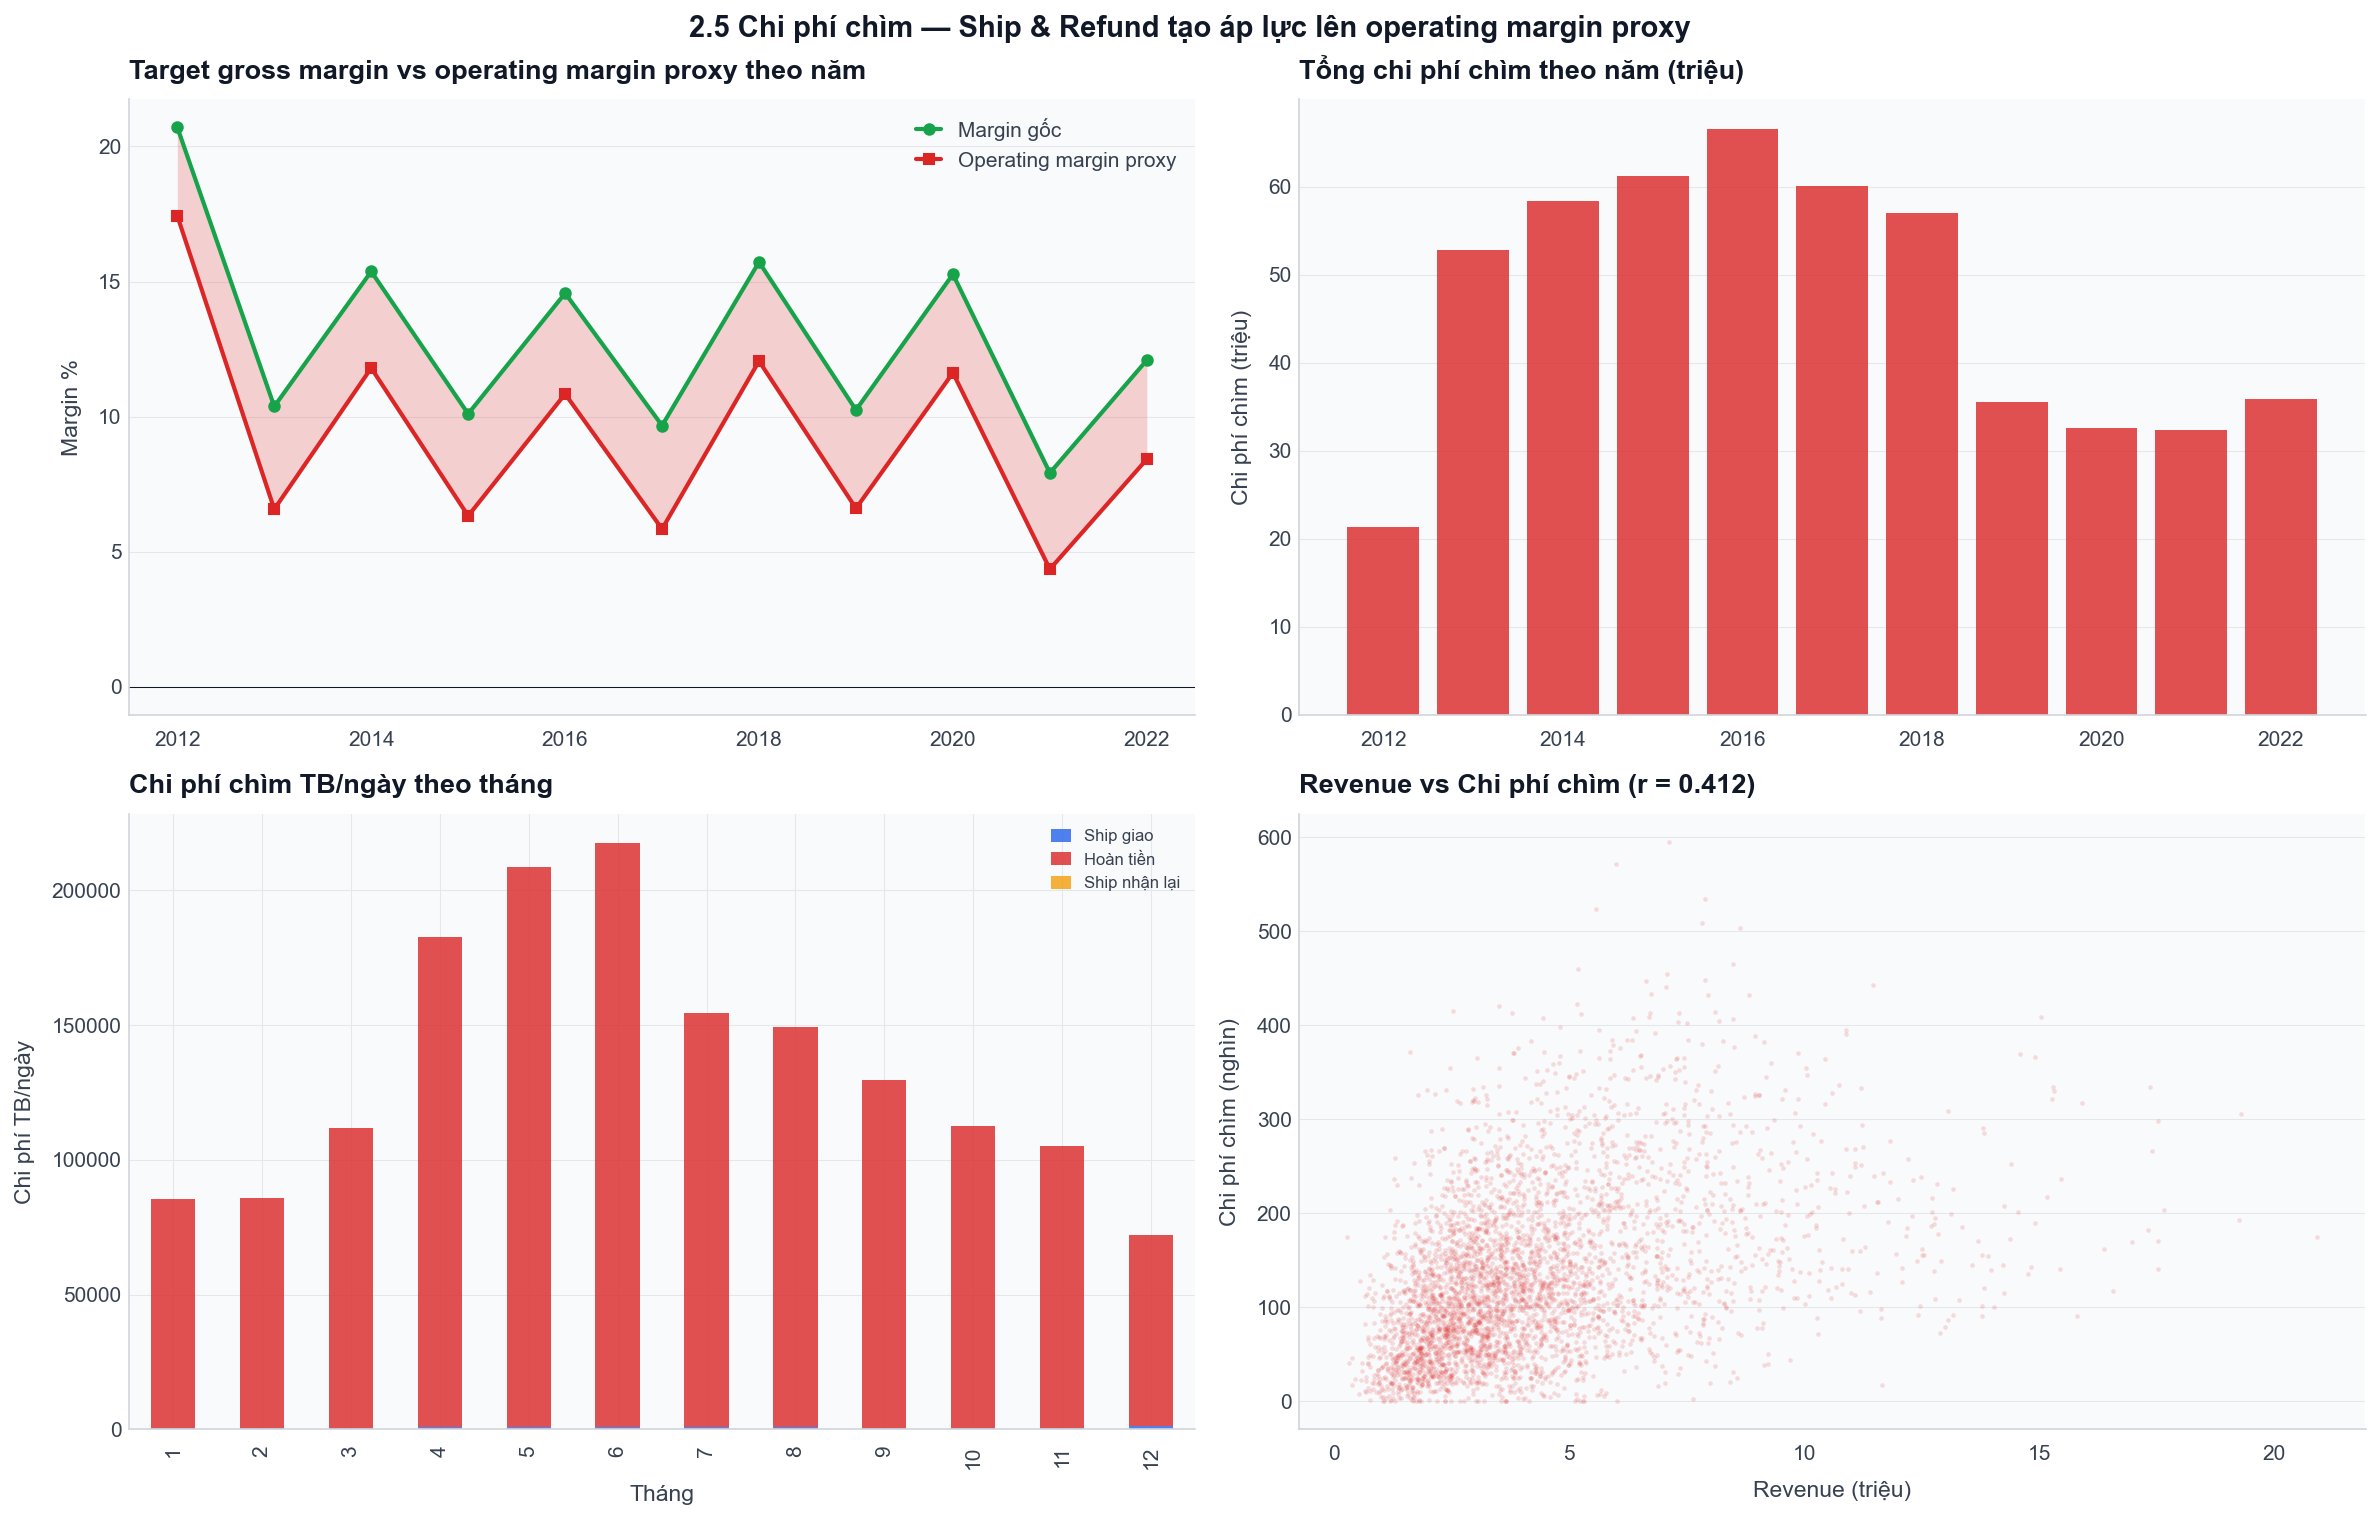


Tháng có chi phí chìm/Revenue cao nhất:
  Tháng 11: chi phí chìm = 4.03% doanh thu
  Tháng 9: chi phí chìm = 3.41% doanh thu
  Tháng 10: chi phí chìm = 3.40% doanh thu


In [12]:
# --- 2.5: Phân tích chi phí vận chuyển (Sunk Cost) ---
print("=" * 70)
print("CHI PHÍ CHÌM — PHÂN TÍCH PHÍ VẬN CHUYỂN")
print("=" * 70)

# 1. Tổng quan phí ship
ship = shipments.copy()
total_ship_cost = ship['shipping_fee'].sum()
avg_ship = ship['shipping_fee'].mean()
n_shipments = len(ship)

print(f"\nTổng số lần giao hàng: {n_shipments:,}")
print(f"Tổng phí ship (Shop chịu): {total_ship_cost:,.0f}")
print(f"Phí ship trung bình / đơn: {avg_ship:,.2f}")

# 2. Phí ship theo trạng thái đơn hàng
ship_status = ship.merge(orders[['order_id','order_status']], on='order_id', how='left')
ship_by_status = ship_status.groupby('order_status').agg(
    N_shipments=('order_id','count'),
    Total_ship=('shipping_fee','sum'),
    Avg_ship=('shipping_fee','mean'),
)
print("\nPhí ship theo trạng thái đơn:")
display(ship_by_status.round(2))

# 3. Phí ship cho đơn bị TRẢ (ship 2 chiều)
returned_orders = orders[orders['order_status']=='returned']['order_id'].values
ship_returned = ship[ship['order_id'].isin(returned_orders)]
ship_cost_returned = ship_returned['shipping_fee'].sum()
# Ship 2 chiều = giao đi + nhận lại
ship_cost_roundtrip = ship_cost_returned * 2  # ước tính ship chiều về = chiều đi

print(f"\n{'─' * 50}")
print(f"📦 CHI PHÍ SHIP CHO ĐƠN TRẢ HÀNG (SHIP 2 CHIỀU):")
print(f"  Số đơn bị trả có ship: {len(ship_returned):,}")
print(f"  Phí ship chiều đi: {ship_cost_returned:,.0f}")
print(f"  Phí ship chiều về (LƯU Ý ĐÂY LÀ TỰ ƯỚC TÍNH = chiều đi): {ship_cost_returned:,.0f}")
print(f"  TỔNG SHIP 2 CHIỀU: {ship_cost_roundtrip:,.0f}")

# 4. Tổng chi phí chìm
refund_total = returns['refund_amount'].sum()
total_sunk = ship_cost_roundtrip + refund_total
print(f"\n{'─' * 50}")
print(f"💸 ESTIMATED SUNK-COST PROXY:")
print(f"  Phí ship toàn bộ (1 chiều):      {total_ship_cost:,.0f}")
print(f"  Phí ship đơn trả (2 chiều thêm (không dám đưa phần ước tính vào vì sợ chưa đúng)): {ship_cost_returned:,.0f}")
print(f"  Tổng refund:                      {refund_total:,.0f}")
print(f"  ─────────────────────────────────────")
print(f"  ƯỚC TÍNH CHI PHÍ PROXY:          {total_ship_cost + ship_cost_returned + refund_total:,.0f}")

# 5. Tính lại Daily Gross Margin có tính Ship
sales_daily = sales.copy()
ship['ship_date'] = pd.to_datetime(ship['ship_date'])
ship_daily = ship.groupby(ship['ship_date'].dt.date)['shipping_fee'].sum().reset_index()
ship_daily.columns = ['date', 'daily_ship_cost']
ship_daily['date'] = pd.to_datetime(ship_daily['date'])

# Return refunds daily
ret_daily = returns.copy()
ret_daily['return_date'] = pd.to_datetime(ret_daily['return_date'])
ret_refund_daily = ret_daily.groupby(ret_daily['return_date'].dt.date).agg(
    daily_refund=('refund_amount','sum'),
    n_returns=('return_id','count'),
).reset_index()
ret_refund_daily.columns = ['date', 'daily_refund', 'n_returns']
ret_refund_daily['date'] = pd.to_datetime(ret_refund_daily['date'])
# Ship chiều về cho returns: count one inferred return shipment per returned order,
# not per returned product line, to avoid over-counting multi-item returns.
ret_ship_orders = (
    ret_daily.groupby('order_id', as_index=False)
    .agg(return_date=('return_date', 'min'))
    .merge(ship[['order_id','shipping_fee']], on='order_id', how='left')
)
ret_ship_daily = ret_ship_orders.groupby(ret_ship_orders['return_date'].dt.date)['shipping_fee'].sum().reset_index()
ret_ship_daily.columns = ['date', 'return_ship_cost']
ret_ship_daily['date'] = pd.to_datetime(ret_ship_daily['date'])

# Merge
margin_df = sales_daily[['Date','Revenue','COGS','Gross_Profit','Margin_Pct']].copy()
margin_df = margin_df.merge(ship_daily, left_on='Date', right_on='date', how='left').drop('date', axis=1)
margin_df = margin_df.merge(ret_refund_daily, left_on='Date', right_on='date', how='left').drop('date', axis=1)
margin_df = margin_df.merge(ret_ship_daily, left_on='Date', right_on='date', how='left').drop('date', axis=1)
margin_df = margin_df.fillna(0)

# Proxy operating margin: starts from gross target revenue, then subtracts COGS,
# outbound ship, refunds by return_date, and inferred return shipping.
# This is a cash/ops stress proxy, NOT the Kaggle target gross margin.
margin_df['Total_Sunk'] = margin_df['daily_ship_cost'] + margin_df['daily_refund'] + margin_df['return_ship_cost']
margin_df['Adj_Operating_Profit_Proxy'] = margin_df['Revenue'] - margin_df['COGS'] - margin_df['Total_Sunk']
margin_df['Adj_Margin_Pct'] = margin_df['Adj_Operating_Profit_Proxy'] / margin_df['Revenue'] * 100

print(f"\n{'═' * 50}")
print(f"SO SÁNH MARGIN TRƯỚC VÀ SAU KHI TÍNH CHI PHÍ CHÌM")
print(f"{'═' * 50}")
print(f"  Target gross margin gốc (Revenue - COGS): {margin_df['Margin_Pct'].mean():.2f}%")
print(f"  Operating margin proxy (trừ ship + refund): {margin_df['Adj_Margin_Pct'].mean():.2f}%")
print(f"  Chênh lệch:                             {margin_df['Adj_Margin_Pct'].mean() - margin_df['Margin_Pct'].mean():.2f} pp")
print(f"  → Chi phí chìm ăn mất {abs(margin_df['Adj_Margin_Pct'].mean() - margin_df['Margin_Pct'].mean()):.2f} percentage points margin mỗi ngày")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Margin comparison time series
margin_df['year'] = margin_df['Date'].dt.year
yearly_margin = margin_df.groupby('year').agg(
    Margin_goc=('Margin_Pct','mean'), Adj_Margin=('Adj_Margin_Pct','mean'),
    Total_Sunk_Year=('Total_Sunk','sum'),
)

axes[0,0].plot(yearly_margin.index, yearly_margin['Margin_goc'], marker='o', label='Margin gốc', color=COLORS['emerald'], linewidth=2)
axes[0,0].plot(yearly_margin.index, yearly_margin['Adj_Margin'], marker='s', label='Operating margin proxy', color=COLORS['red'], linewidth=2)
axes[0,0].fill_between(yearly_margin.index, yearly_margin['Adj_Margin'], yearly_margin['Margin_goc'], alpha=0.2, color=COLORS['red'])
axes[0,0].set_title('Target gross margin vs operating margin proxy theo năm', fontweight='bold')
axes[0,0].set_ylabel('Margin %')
axes[0,0].legend()
axes[0,0].axhline(y=0, color=CLR_TITLE, linewidth=0.5)

# 2) Sunk cost breakdown by year
axes[0,1].bar(yearly_margin.index, yearly_margin['Total_Sunk_Year']/1e6, color=COLORS['red'], alpha=0.8)
axes[0,1].set_title('Tổng chi phí chìm theo năm (triệu)', fontweight='bold')
axes[0,1].set_ylabel('Chi phí chìm (triệu)')

# 3) Daily sunk cost components
margin_df['month'] = margin_df['Date'].dt.month
monthly_sunk = margin_df.groupby('month').agg(
    Ship_1_chieu=('daily_ship_cost','mean'), Refund=('daily_refund','mean'),
    Ship_ve=('return_ship_cost','mean'),
)
monthly_sunk.plot(kind='bar', stacked=True, ax=axes[1,0], color=[COLORS['blue'], COLORS['red'], SEQ_AMBER[2]], alpha=0.8)
axes[1,0].set_title('Chi phí chìm TB/ngày theo tháng', fontweight='bold')
axes[1,0].set_ylabel('Chi phí TB/ngày')
axes[1,0].set_xlabel('Tháng')
axes[1,0].legend(['Ship giao', 'Hoàn tiền', 'Ship nhận lại'], fontsize=8)

# 4) Scatter: Sunk cost vs Revenue
axes[1,1].scatter(margin_df['Revenue']/1e6, margin_df['Total_Sunk']/1e3, alpha=0.15, s=5, color=COLORS['red'])
r_sunk = margin_df['Revenue'].corr(margin_df['Total_Sunk'])
axes[1,1].set_xlabel('Revenue (triệu)')
axes[1,1].set_ylabel('Chi phí chìm (nghìn)')
axes[1,1].set_title(f'Revenue vs Chi phí chìm (r = {r_sunk:.3f})', fontweight='bold')

plt.tight_layout()
plt.suptitle('2.5 Chi phí chìm — Ship & Refund tạo áp lực lên operating margin proxy', fontweight='bold', fontsize=14, y=1.01)
plt.show()

# Tháng nào sunk cost nặng nhất?
print("\nTháng có chi phí chìm/Revenue cao nhất:")
monthly_ratio = margin_df.groupby('month').agg(
    Sunk=('Total_Sunk','sum'), Rev=('Revenue','sum'),
)
monthly_ratio['Sunk_pct'] = monthly_ratio['Sunk'] / monthly_ratio['Rev'] * 100
for m in monthly_ratio['Sunk_pct'].nlargest(3).index:
    print(f"  Tháng {m}: chi phí chìm = {monthly_ratio.loc[m,'Sunk_pct']:.2f}% doanh thu")


---
# TẦNG 3: PREDICTIVE — Điều gì sẽ xảy ra?

> Mục tiêu: Nhận diện xu hướng, seasonality lặp lại, dấu hiệu báo trước (leading indicator).


### 3.1 Xu hướng Margin — Đang đi về đâu?

XU HƯỚNG: DOANH THU TĂNG NHƯNG TARGET GROSS MARGIN GIẢM (all-status)


,Revenue,COGS,Days,Weighted_Margin,YoY_Rev_%,YoY_Margin_chg
year,,,,,,
2012,7.414977e+08,5.874619e+08,181,20.8,NaN,NaN
2013,1.657169e+09,1.465980e+09,365,11.5,123.5,-9.3
2014,1.871846e+09,1.574607e+09,365,15.9,13.0,4.4
2015,1.889934e+09,1.665442e+09,365,11.9,1.0,-4.0
2016,2.104641e+09,1.780559e+09,366,15.4,11.4,3.5
2017,1.911164e+09,1.694386e+09,365,11.3,-9.2,-4.1
2018,1.850122e+09,1.542176e+09,365,16.6,-3.2,5.3
2019,1.136801e+09,1.005203e+09,365,11.6,-38.6,-5.0
2020,1.054512e+09,8.860851e+08,366,16.0,-7.2,4.4



Hồi quy tuyến tính Margin ~ Year:
  Slope: -0.42 pp/năm (giảm 0.42 percentage point mỗi năm)
  R²: 0.182
  p-value: 0.190959


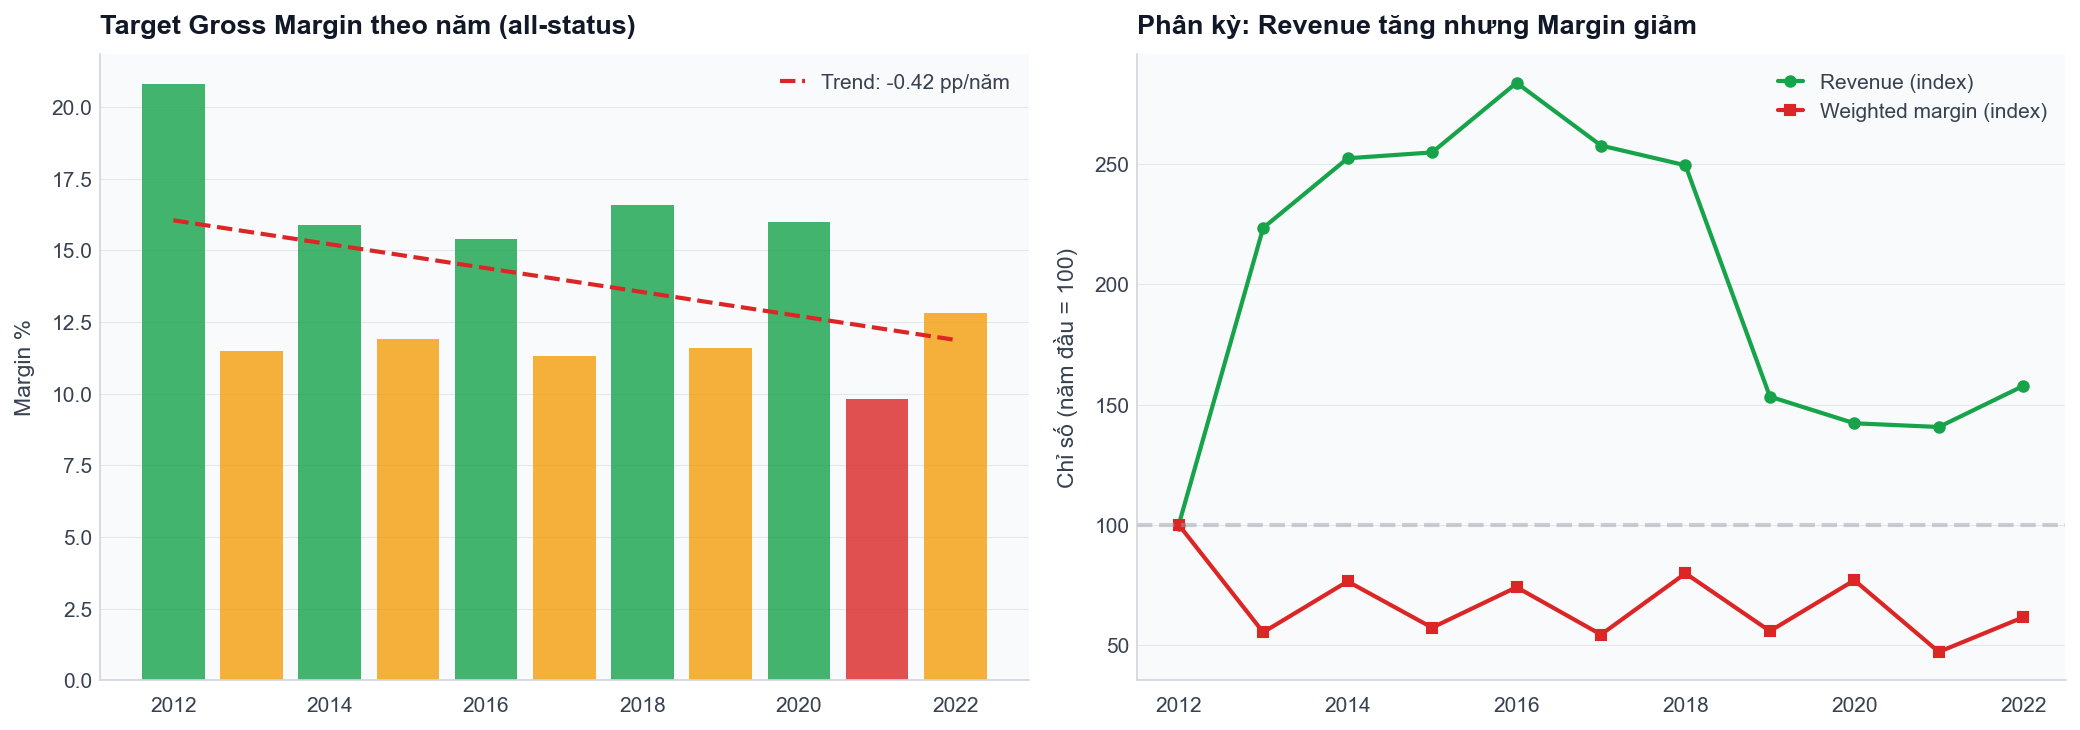


🔮 DỰ BÁO (Linear Extrapolation):
  Margin 2023 (ước): 11.5%
  Margin 2024 (ước): 11.0%
  → Nếu cấu trúc target gross margin tiếp diễn, chỉ số này sẽ về gần 0 vào khoảng năm 2050

⚠ Lưu ý: Đây là gross margin (Revenue-COGS)/Revenue trên ALL order_status.
  Net committed margin (sau discount, loại cancelled/created) sẽ thấp hơn ~4pp. Không dùng riêng gross trend này để kết luận business profitability.


In [13]:
# --- Predictive: Margin trend ---
yearly_kpi = sales.groupby('year').agg(
    Revenue=('Revenue','sum'), COGS=('COGS','sum'),
    Days=('Date','count'),
)
# Weighted yearly margin: mean(daily margin %) can distort yearly profitability.
yearly_kpi['Weighted_Margin'] = (yearly_kpi['Revenue'] - yearly_kpi['COGS']) / yearly_kpi['Revenue'] * 100
yearly_kpi = yearly_kpi.round(1)
yearly_kpi['YoY_Rev_%'] = yearly_kpi['Revenue'].pct_change() * 100
yearly_kpi['YoY_Margin_chg'] = yearly_kpi['Weighted_Margin'].diff()

print("=" * 60)
print("XU HƯỚNG: DOANH THU TĂNG NHƯNG TARGET GROSS MARGIN GIẢM (all-status)")
print("=" * 60)
display(yearly_kpi.round(1))

# Linear trend of margin
X = yearly_kpi.index.values
Y = yearly_kpi['Weighted_Margin'].values
slope, intercept, r_val, p_val, std_err = stats.linregress(X, Y)

print(f"\nHồi quy tuyến tính Margin ~ Year:")
print(f"  Slope: {slope:.2f} pp/năm (giảm {abs(slope):.2f} percentage point mỗi năm)")
print(f"  R²: {r_val**2:.3f}")
print(f"  p-value: {p_val:.6f}")

# Dự báo 2023-2024
margin_2023 = slope * 2023 + intercept
margin_2024 = slope * 2024 + intercept

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(X, Y, color=[COLORS['emerald'] if m > 15 else SEQ_AMBER[2] if m > 10 else COLORS['red'] for m in Y], alpha=0.8)
axes[0].plot(X, slope*X + intercept, color=COLORS['red'], linestyle='--', linewidth=2, label=f'Trend: {slope:+.2f} pp/năm')
axes[0].axhline(y=0, color=CLR_TITLE, linewidth=0.5)
axes[0].set_title('Target Gross Margin theo năm (all-status)', fontweight='bold')
axes[0].set_ylabel('Margin %')
axes[0].legend()

# Revenue vs Margin divergence
ax2 = axes[1]
ax2.plot(X, yearly_kpi['Revenue']/yearly_kpi['Revenue'].iloc[0]*100, marker='o', color=COLORS['emerald'], linewidth=2, label='Revenue (index)')
ax2.plot(X, yearly_kpi['Weighted_Margin']/yearly_kpi['Weighted_Margin'].iloc[0]*100, marker='s', color=COLORS['red'], linewidth=2, label='Weighted margin (index)')
ax2.set_title('Phân kỳ: Revenue tăng nhưng Margin giảm', fontweight='bold')
ax2.set_ylabel('Chỉ số (năm đầu = 100)')
ax2.legend()
ax2.axhline(y=100, color=CLR_MUTED, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\n🔮 DỰ BÁO (Linear Extrapolation):")
print(f"  Margin 2023 (ước): {margin_2023:.1f}%")
print(f"  Margin 2024 (ước): {margin_2024:.1f}%")
print(f"  → Nếu cấu trúc target gross margin tiếp diễn, chỉ số này sẽ về gần 0 vào khoảng năm {int(-intercept/slope)}")
print(f"\n⚠ Lưu ý: Đây là gross margin (Revenue-COGS)/Revenue trên ALL order_status.")
print(f"  Net committed margin (sau discount, loại cancelled/created) sẽ thấp hơn ~4pp. Không dùng riêng gross trend này để kết luận business profitability.")


### 3.2 Dấu hiệu báo trước (Leading Indicators)

LEADING INDICATOR 1: Site Traffic (Sessions toàn site)
  Trend sessions 2 năm gần đây: -2,028 sessions/năm
  R²: 0.017, p-value: 0.7591
  → Traffic site GIẢM
  ⚠ Corr(sessions, daily_orders) ≈ 0.19 — traffic yếu như leading indicator cho Revenue

LEADING INDICATOR 2: Retention Rate theo first-purchase cohort


year_offset,0,1,2,3,4,5,6,7,8,9,10
cohort_year,,,,,,,,,,,
2012,100.0,62.6,62.8,63.5,64.0,61.7,59.6,45.1,40.9,40.2,40.8
2013,100.0,49.4,49.8,49.6,48.2,46.3,33.8,29.9,29.4,30.3,NaN
2014,100.0,34.8,35.3,33.6,32.0,21.8,19.5,18.8,19.7,NaN,NaN
2015,100.0,27.4,27.3,25.0,16.2,14.2,14.0,14.2,NaN,NaN,NaN
2016,100.0,21.4,20.2,12.6,10.9,10.5,10.9,NaN,NaN,NaN,NaN
2017,100.0,15.6,11.4,9.1,9.2,8.4,NaN,NaN,NaN,NaN,NaN
2018,100.0,9.4,8.0,7.6,8.6,NaN,NaN,NaN,NaN,NaN,NaN
2019,100.0,7.7,7.2,7.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020,100.0,6.3,6.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


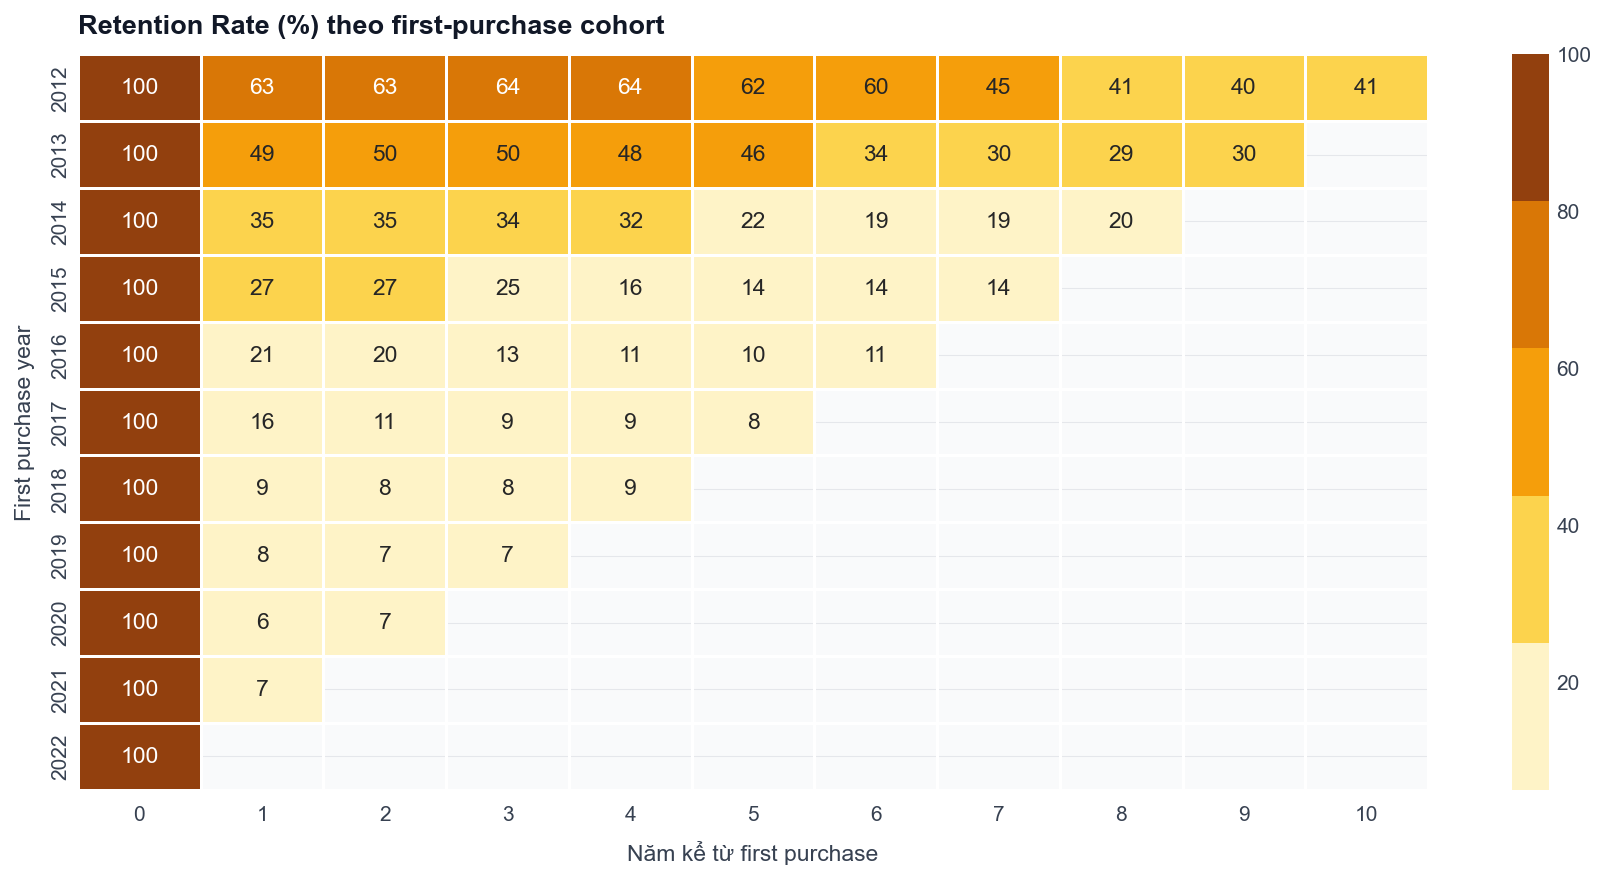


Trend retention năm đầu tiên: -6.04 pp/năm
  → Retention GIẢM dần qua các cohort

LEADING INDICATOR 3: Acquisition channel — chỉ đọc phần post-signup hợp lệ


,N_customers,N_any_order,N_valid_post_signup_order,Median_days_to_first_valid,Any_order_rate_%,Post_signup_observable_rate_%
acquisition_channel,,,,,,
direct,9803,7127,799,567.0,72.7,8.2
email_campaign,14674,10584,1176,615.0,72.1,8.0
organic_search,36450,26257,2853,549.0,72.0,7.8
paid_search,24285,17508,1940,619.0,72.1,8.0
referral,12270,8847,962,601.5,72.1,7.8
social_media,24448,17516,1890,564.0,71.6,7.7



  → Kênh có post-signup observable conversion cao nhất: direct (8.2%)
  → Cảnh báo dữ liệu: 78,219 khách có first purchase trước signup_date; chỉ 9,620 khách có timing hợp lệ để diễn giải days_to_first.
  → Không dùng signup_date thô để kết luận causal về acquisition nếu chưa xử lý cohort/timing.


In [14]:
# --- Predictive: Leading indicators ---
# 1) Site-level traffic trend (sessions = tổng daily toàn site — B-TER.2)
# Lưu ý: traffic_source là nhãn 1/ngày, KHÔNG phải attribution → không tách theo source
wt_source = web_traffic.copy()
wt_source['quarter'] = wt_source['date'].dt.to_period('Q')

wt_q = wt_source.groupby('quarter').agg(
    avg_sessions=('sessions','mean'),
    avg_bounce=('bounce_rate','mean'),
).reset_index()
wt_q['quarter_num'] = range(len(wt_q))

if len(wt_q) > 4:
    recent = wt_q.tail(8)
    slope_s, _, r_s, p_s, _ = stats.linregress(recent['quarter_num'], recent['avg_sessions'])

    print("=" * 60)
    print("LEADING INDICATOR 1: Site Traffic (Sessions toàn site)")
    print("=" * 60)
    print(f"  Trend sessions 2 năm gần đây: {slope_s*4:+,.0f} sessions/năm")
    print(f"  R²: {r_s**2:.3f}, p-value: {p_s:.4f}")
    trend_dir = 'TĂNG' if slope_s > 0 else 'GIẢM'
    print(f"  → Traffic site {trend_dir}")
    print(f"  ⚠ Corr(sessions, daily_orders) ≈ 0.19 — traffic yếu như leading indicator cho Revenue")

# 2) Purchase-cohort retention
# signup_date không thể dùng trực tiếp làm cohort vì phần lớn first_order xảy ra trước signup_date.
# Vì vậy retention dùng first committed purchase cohort để tránh kết luận sai.
print("\n" + "=" * 60)
print("LEADING INDICATOR 2: Retention Rate theo first-purchase cohort")
print("=" * 60)

orders_fulfilled = orders[~orders['order_status'].isin(['cancelled', 'created'])][['customer_id','order_date']].copy()
orders_fulfilled['order_year'] = orders_fulfilled['order_date'].dt.year
first_purchase = orders_fulfilled.groupby('customer_id')['order_date'].min().reset_index()
first_purchase.columns = ['customer_id','first_purchase_date']
first_purchase['cohort_year'] = first_purchase['first_purchase_date'].dt.year

orders_cust = orders_fulfilled.merge(first_purchase[['customer_id','cohort_year']], on='customer_id', how='left')
orders_cust['year_since_first_purchase'] = orders_cust['order_year'] - orders_cust['cohort_year']

cohort_sizes = first_purchase.groupby('cohort_year')['customer_id'].nunique()
retention_data = orders_cust[orders_cust['year_since_first_purchase'] >= 0].groupby(
    ['cohort_year','year_since_first_purchase'])['customer_id'].nunique().reset_index()
retention_data.columns = ['cohort_year','year_offset','active_customers']
retention_data = retention_data.merge(cohort_sizes.reset_index().rename(columns={'customer_id':'cohort_size'}), on='cohort_year')
retention_data['retention_%'] = retention_data['active_customers'] / retention_data['cohort_size'] * 100

pivot_ret = retention_data.pivot(index='cohort_year', columns='year_offset', values='retention_%')
display(pivot_ret.round(1))

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_ret, annot=True, fmt='.0f', cmap=sns.color_palette(SEQ_AMBER, as_cmap=True), ax=ax, linewidths=0.5)
ax.set_title('Retention Rate (%) theo first-purchase cohort', fontweight='bold')
ax.set_xlabel('Năm kể từ first purchase')
ax.set_ylabel('First purchase year')
plt.tight_layout()
plt.show()

if 1 in pivot_ret.columns:
    y1_retention = pivot_ret[1].dropna()
    if len(y1_retention) > 2:
        slope_r, _, r_r, _, _ = stats.linregress(range(len(y1_retention)), y1_retention.values)
        print(f"\nTrend retention năm đầu tiên: {slope_r:+.2f} pp/năm")
        print(f"  → Retention {'GIẢM' if slope_r < 0 else 'TĂNG'} dần qua các cohort")

# 3) Acquisition channel effectiveness
print("\n" + "=" * 60)
print("LEADING INDICATOR 3: Acquisition channel — chỉ đọc phần post-signup hợp lệ")
print("=" * 60)

cust_channel = customers[['customer_id','acquisition_channel','signup_date']].copy()
cust_channel = cust_channel.merge(first_purchase[['customer_id','first_purchase_date']], on='customer_id', how='left')
cust_channel['has_order'] = cust_channel['first_purchase_date'].notna()
cust_channel['days_to_first'] = (cust_channel['first_purchase_date'] - cust_channel['signup_date']).dt.days
cust_channel['valid_post_signup_order'] = cust_channel['days_to_first'].ge(0)
invalid_timing = cust_channel['days_to_first'].lt(0).sum()
valid_timing = cust_channel['days_to_first'].ge(0).sum()

channel_eff = cust_channel.groupby('acquisition_channel').agg(
    N_customers=('customer_id','count'),
    N_any_order=('has_order','sum'),
    N_valid_post_signup_order=('valid_post_signup_order','sum'),
    Median_days_to_first_valid=('days_to_first', lambda s: s[s >= 0].median()),
)
channel_eff['Any_order_rate_%'] = channel_eff['N_any_order'] / channel_eff['N_customers'] * 100
channel_eff['Post_signup_observable_rate_%'] = channel_eff['N_valid_post_signup_order'] / channel_eff['N_customers'] * 100
display(channel_eff.round(1))

best_ch = channel_eff['Post_signup_observable_rate_%'].idxmax()
best_rate = channel_eff.loc[best_ch, 'Post_signup_observable_rate_%']
print(f"\n  → Kênh có post-signup observable conversion cao nhất: {best_ch} ({best_rate:.1f}%)")
print(f"  → Cảnh báo dữ liệu: {invalid_timing:,} khách có first purchase trước signup_date; chỉ {valid_timing:,} khách có timing hợp lệ để diễn giải days_to_first.")
print("  → Không dùng signup_date thô để kết luận causal về acquisition nếu chưa xử lý cohort/timing.")


### 3.3 Seasonality lặp lại — Pattern có thể dự đoán

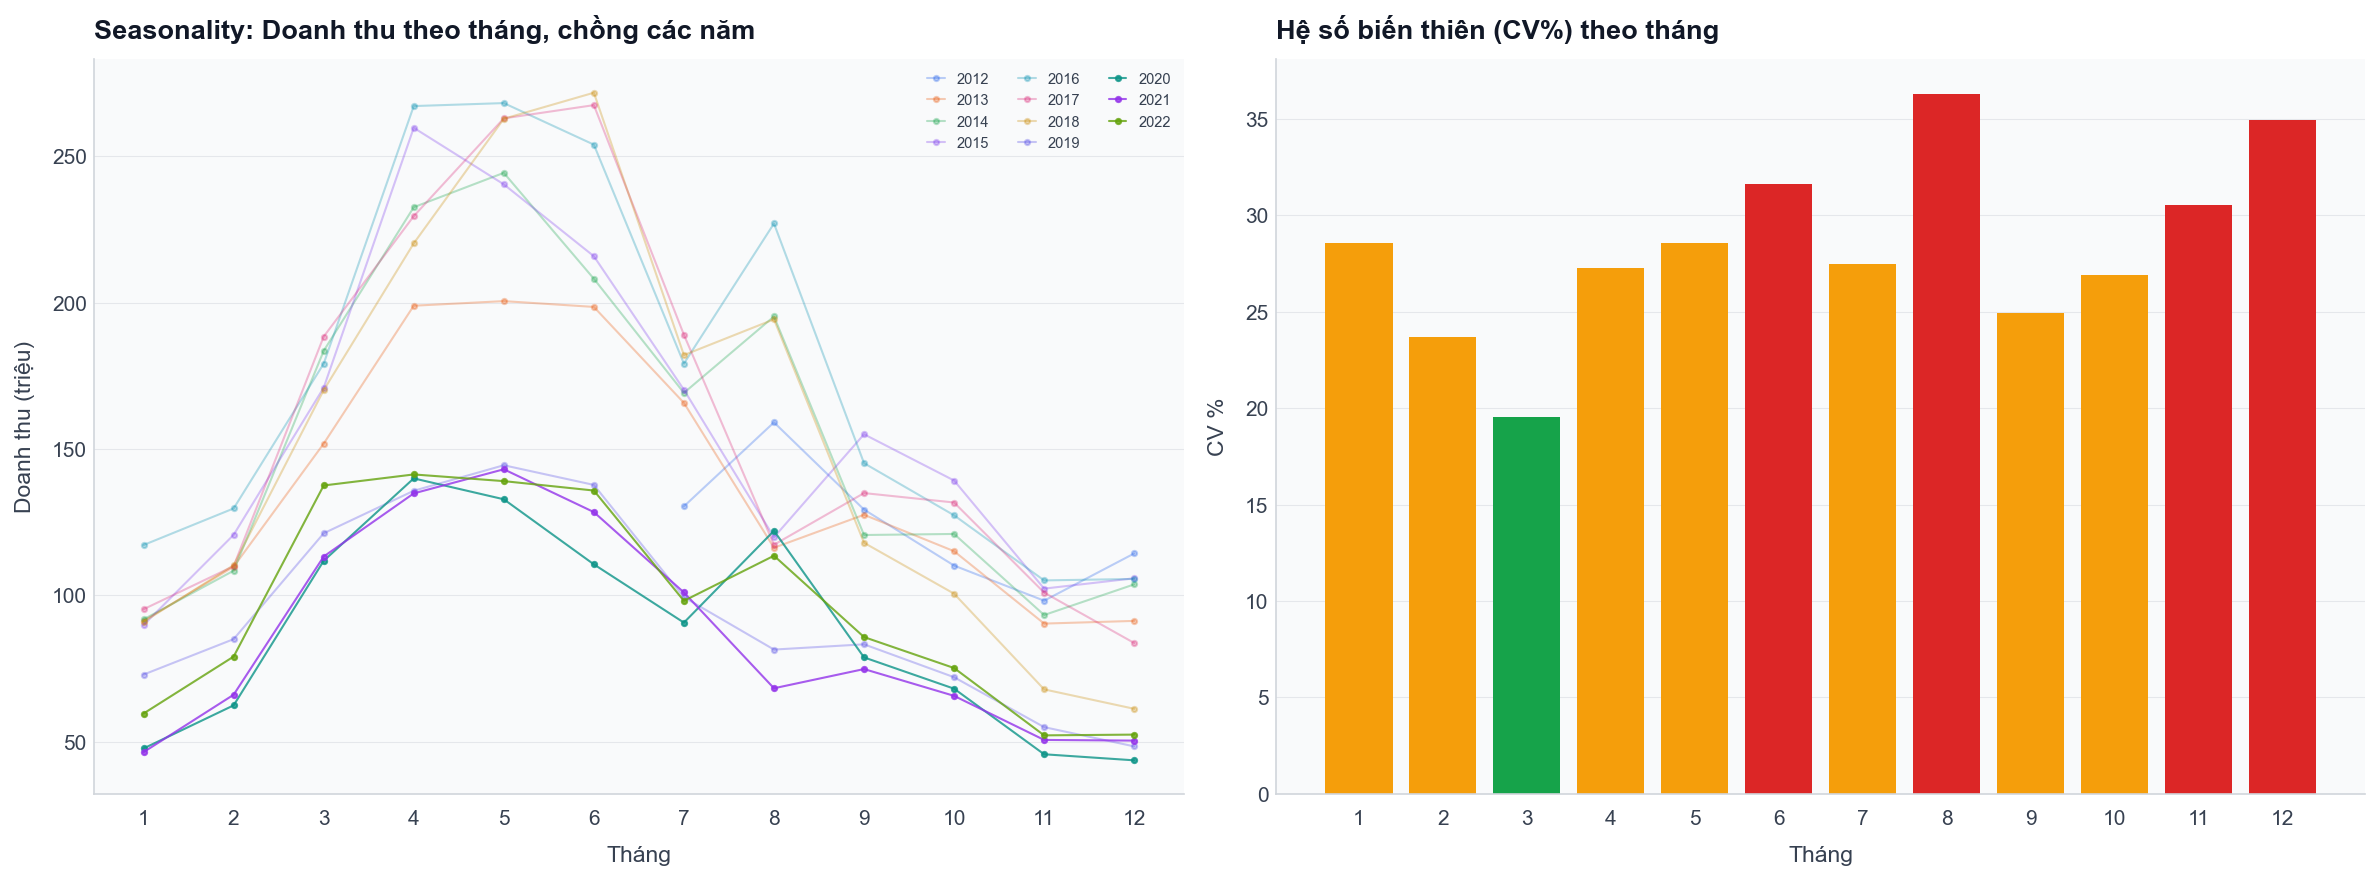


🔮 NHẬN XÉT PREDICTIVE:
  • Tháng biến thiên cao (khó dự đoán): [1, 4, 5, 6, 7, 8, 10, 11, 12]
  • Tháng ổn định (dễ dự đoán): []
  • Seasonality LẶP LẠI rõ ràng → model cần seasonal component


In [15]:
# --- Predictive: Seasonal decomposition ---
# Revenue by month across all years
monthly_pattern = sales.groupby(['year','month'])['Revenue'].sum().reset_index()
monthly_pivot = monthly_pattern.pivot(index='month', columns='year', values='Revenue')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overlay monthly pattern for each year
for y in monthly_pivot.columns:
    alpha = 0.3 if y < 2020 else 0.8
    axes[0].plot(monthly_pivot.index, monthly_pivot[y]/1e6, marker='.', alpha=alpha, linewidth=1, label=str(y))
axes[0].set_title('Seasonality: Doanh thu theo tháng, chồng các năm', fontweight='bold')
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Doanh thu (triệu)')
axes[0].set_xticks(range(1,13))
axes[0].legend(fontsize=7, ncol=3)

# Monthly coefficient of variation
monthly_cv = monthly_pivot.std(axis=1) / monthly_pivot.mean(axis=1) * 100
axes[1].bar(monthly_cv.index, monthly_cv.values, color=[COLORS['red'] if cv > 30 else SEQ_AMBER[2] if cv > 20 else COLORS['emerald'] for cv in monthly_cv])
axes[1].set_title('Hệ số biến thiên (CV%) theo tháng', fontweight='bold')
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('CV %')
axes[1].set_xticks(range(1,13))

plt.tight_layout()
plt.show()

print("\n🔮 NHẬN XÉT PREDICTIVE:")
high_cv = monthly_cv[monthly_cv > 25].index.tolist()
low_cv = monthly_cv[monthly_cv < 15].index.tolist()
print(f"  • Tháng biến thiên cao (khó dự đoán): {high_cv}")
print(f"  • Tháng ổn định (dễ dự đoán): {low_cv}")
print(f"  • Seasonality LẶP LẠI rõ ràng → model cần seasonal component")


---
# TẦNG 4: PRESCRIPTIVE — Doanh nghiệp cần làm gì?

> Mục tiêu: Đề xuất CỤ THỂ, có số liệu, có trade-off, có metric đo lường.

**Template:**
```
[Đề xuất cụ thể]
→ Dựa trên: [insight từ tầng 1+2+3]
→ Kỳ vọng: [con số cụ thể]
→ Cách đo: [metric]
→ Rủi ro: [trade-off]
```


In [16]:
# --- Prescriptive: Tính toán số liệu cho đề xuất ---
print("=" * 70)
print("ĐỀ XUẤT HÀNH ĐỘNG — CÓ SỐ LIỆU CỤ THỂ")
print("=" * 70)

# ===== ĐỀ XUẤT 1: Cắt giảm Promo không hiệu quả =====
promo_orders = oi[(oi['has_promo']) & (oi['is_committed'])]
no_promo_orders = oi[(~oi['has_promo']) & (oi['is_committed'])]
_oi_c34 = oi[oi['is_committed']]

margin_promo = promo_orders['line_profit'].sum() / promo_orders['line_net'].sum() * 100
margin_no_promo = no_promo_orders['line_profit'].sum() / no_promo_orders['line_net'].sum() * 100
baseline_net_profit = _oi_c34['line_profit'].sum()
baseline_net_margin = baseline_net_profit / _oi_c34['line_net'].sum() * 100
total_discount_given = promo_orders['discount_amount'].sum()
n_promo_days = _oi_c34.groupby(_oi_c34['order_date'])['has_promo'].mean()
pct_heavy_promo_days = (n_promo_days > 0.5).mean() * 100

# Nếu giảm 30% promo, ước tính margin recovery
promo_rev = promo_orders['line_net'].sum()
recovery_pct = 0.30  # giả sử cắt 30% promo
margin_gap = margin_no_promo - margin_promo  # pp
estimated_margin_gain = promo_rev * recovery_pct * margin_gap / 100

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║  ĐỀ XUẤT 1: CẮT GIẢM 30% CHƯƠNG TRÌNH KHUYẾN MÃI KÉM HIỆU QUẢ ║
╚══════════════════════════════════════════════════════════════════╝

→ Dựa trên:
  • Net fulfilled margin khi có promo: {margin_promo:.1f}% vs không promo: {margin_no_promo:.1f}% (chênh {margin_gap:.1f}pp)
  • Tổng discount đã phát: {total_discount_given:,.0f}
  • {pct_heavy_promo_days:.0f}% số ngày có >50% fulfilled lines gắn promo
  • Promo không tăng net fulfilled revenue ngày đó (r = {corr_rev_promo:.3f}) — bằng chứng cannibalization

→ Kỳ vọng:
  • Phục hồi margin ước tính: {estimated_margin_gain:,.0f} (tương đương {estimated_margin_gain/baseline_net_profit*100:.1f}% net fulfilled profit)
  • Net fulfilled margin tăng từ {baseline_net_margin:.1f}% lên ~{baseline_net_margin + margin_gap * recovery_pct * 0.5:.1f}%

→ Cách đo:
  • Tracking: Net fulfilled margin % hàng tháng (target > 15%)
  • A/B test: Chạy 1 tháng giảm promo ở 1 region, so net sales/margin với region control

→ Rủi ro:
  • Giảm promo có thể mất khách hàng nhạy giá (price-sensitive)
  • Ước tính 5-10% giảm volume tạm thời trong 1-2 tháng đầu
  • Trade-off: Hy sinh volume ngắn hạn để cải thiện profitability dài hạn
""")


ĐỀ XUẤT HÀNH ĐỘNG — CÓ SỐ LIỆU CỤ THỂ

╔══════════════════════════════════════════════════════════════════╗
║  ĐỀ XUẤT 1: CẮT GIẢM 30% CHƯƠNG TRÌNH KHUYẾN MÃI KÉM HIỆU QUẢ ║
╚══════════════════════════════════════════════════════════════════╝

→ Dựa trên:
  • Net fulfilled margin khi có promo: -14.4% vs không promo: 20.0% (chênh 34.4pp)
  • Tổng discount đã phát: 671,912,639
  • 37% số ngày có >50% fulfilled lines gắn promo
  • Promo không tăng net fulfilled revenue ngày đó (r = -0.212) — bằng chứng cannibalization

→ Kỳ vọng:
  • Phục hồi margin ước tính: 433,428,603 (tương đương 31.8% net fulfilled profit)
  • Net fulfilled margin tăng từ 9.7% lên ~14.8%

→ Cách đo:
  • Tracking: Net fulfilled margin % hàng tháng (target > 15%)
  • A/B test: Chạy 1 tháng giảm promo ở 1 region, so net sales/margin với region control

→ Rủi ro:
  • Giảm promo có thể mất khách hàng nhạy giá (price-sensitive)
  • Ước tính 5-10% giảm volume tạm thời trong 1-2 tháng đầu
  • Trade-off: Hy sinh volume ngắn h

In [17]:
# ===== ĐỀ XUẤT 2: Cải thiện Size Guide =====
wrong_size_returns = returns[returns['return_reason']=='wrong_size'] if 'wrong_size' in returns['return_reason'].values else pd.DataFrame()
wrong_size_refund = wrong_size_returns['refund_amount'].sum() if len(wrong_size_returns) > 0 else 0
total_refund = returns['refund_amount'].sum()
wrong_size_pct = len(wrong_size_returns) / len(returns) * 100 if len(returns) > 0 else 0

# Chi phí xử lý 1 đơn trả hàng (ước tính)
avg_refund = returns['refund_amount'].mean()
logistics_cost_per_return = avg_refund * 0.15  # 15% logistics overhead

total_return_cost = len(returns) * logistics_cost_per_return + total_refund
potential_save = wrong_size_refund + len(wrong_size_returns) * logistics_cost_per_return

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║  ĐỀ XUẤT 2: CẢI THIỆN SIZE GUIDE & BỘ LỌC SIZE TRÊN WEBSITE   ║
╚══════════════════════════════════════════════════════════════════╝

→ Dựa trên:
  • 'wrong_size' chiếm {wrong_size_pct:.1f}% lý do trả hàng (hàng đầu)
  • Tổng refund do sai size: {wrong_size_refund:,.0f}
  • Tỷ lệ trả hàng tương đương ở TẤT CẢ size → vấn đề hệ thống, không phải size cụ thể

→ Kỳ vọng:
  • Giảm 40-60% đơn trả do wrong_size → tiết kiệm {potential_save*0.5:,.0f} chi phí
  • Giảm return rate từ {return_rate:.2f}% xuống ~{return_rate * (1 - wrong_size_pct/100*0.5):.2f}%
  • Cải thiện NPS và customer satisfaction

→ Cách đo:
  • Tracking: Return rate (target < 4%), % wrong_size trong return reason (target < 15%)
  • Survey: Hỏi khách "Size có đúng không?" sau khi nhận hàng

→ Rủi ro:
  • Chi phí phát triển size guide: ~100-200 giờ dev
  • Cần data đo lường cơ thể khách hàng (có thể dùng crowdsource)
  • Trade-off: Đầu tư upfront nhưng ROI dài hạn
""")



╔══════════════════════════════════════════════════════════════════╗
║  ĐỀ XUẤT 2: CẢI THIỆN SIZE GUIDE & BỘ LỌC SIZE TRÊN WEBSITE   ║
╚══════════════════════════════════════════════════════════════════╝

→ Dựa trên:
  • 'wrong_size' chiếm 35.0% lý do trả hàng (hàng đầu)
  • Tổng refund do sai size: 176,687,201
  • Tỷ lệ trả hàng tương đương ở TẤT CẢ size → vấn đề hệ thống, không phải size cụ thể

→ Kỳ vọng:
  • Giảm 40-60% đơn trả do wrong_size → tiết kiệm 101,735,641 chi phí
  • Giảm return rate từ 6.22% xuống ~5.13%
  • Cải thiện NPS và customer satisfaction

→ Cách đo:
  • Tracking: Return rate (target < 4%), % wrong_size trong return reason (target < 15%)
  • Survey: Hỏi khách "Size có đúng không?" sau khi nhận hàng

→ Rủi ro:
  • Chi phí phát triển size guide: ~100-200 giờ dev
  • Cần data đo lường cơ thể khách hàng (có thể dùng crowdsource)
  • Trade-off: Đầu tư upfront nhưng ROI dài hạn



In [18]:
# ===== ĐỀ XUẤT 3: Tập trung vào Champions & Win-back At Risk =====
# RFM quick
ref_date = orders['order_date'].max() + pd.Timedelta(days=1)
rfm = orders[~orders['order_status'].isin(['cancelled', 'created'])].groupby('customer_id').agg(
    Recency=('order_date', lambda x: (ref_date - x.max()).days),
    Frequency=('order_id','nunique'),
).reset_index()
monetary = oi[oi['is_committed']].groupby('customer_id')['line_net'].sum().reset_index()
monetary.columns = ['customer_id','Monetary']
rfm = rfm.merge(monetary, on='customer_id', how='left')

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5])

def rfm_seg(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >= 4 and f >= 4 and m >= 4: return 'Champions'
    elif r >= 3 and f >= 3: return 'Loyal'
    elif r >= 4 and f <= 2: return 'Khách mới'
    elif r <= 2 and f >= 3: return 'Nguy cơ mất'
    elif r <= 2 and f <= 2 and m >= 3: return 'Mất (giá trị cao)'
    elif r <= 2: return 'Đã mất' 
    else: return 'Trung bình'

rfm['Segment'] = rfm.apply(rfm_seg, axis=1)
seg = rfm.groupby('Segment').agg(N=('customer_id','count'), Rev=('Monetary','sum'), Avg_Rev=('Monetary','mean')).sort_values('Rev', ascending=False)
seg['Cust_%'] = seg['N'] / seg['N'].sum() * 100
seg['Rev_%'] = seg['Rev'] / seg['Rev'].sum() * 100

champ_rev = seg.loc['Champions','Rev'] if 'Champions' in seg.index else 0
champ_n = seg.loc['Champions','N'] if 'Champions' in seg.index else 0
at_risk_rev = seg.loc['Nguy cơ mất','Rev'] if 'Nguy cơ mất' in seg.index else 0
at_risk_n = seg.loc['Nguy cơ mất','N'] if 'Nguy cơ mất' in seg.index else 0

# Win-back estimate: nếu recover 20% At Risk
winback_target = 0.20  # Assumption: 20% win-back rate (historical range 10–25% cho retention campaigns)
recover_rev = at_risk_rev * winback_target
avg_at_risk_rev = seg.loc['Nguy cơ mất','Avg_Rev'] if 'Nguy cơ mất' in seg.index else 0

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║  ĐỀ XUẤT 3: GIỮ CHÂN CHAMPIONS + WIN-BACK KHÁCH NGUY CƠ MẤT   ║
╚══════════════════════════════════════════════════════════════════╝

→ Dựa trên:
  • Champions: {champ_n:,} khách ({seg.loc['Champions','Cust_%']:.1f}%) tạo {seg.loc['Champions','Rev_%']:.1f}% doanh thu
  • Nguy cơ mất: {at_risk_n:,} khách — từng mua nhiều nhưng lâu không quay lại
  • Đã mất hoàn toàn: {seg.loc['Đã mất','N'] if 'Đã mất' in seg.index else 0:,} khách

→ Kỳ vọng:
  • Win-back 20% khách Nguy cơ mất → phục hồi {recover_rev:,.0f} doanh thu
  • Mỗi khách At Risk TB chi {avg_at_risk_rev:,.0f} → cần {int(at_risk_n*winback_target):,} khách quay lại
  • Loyalty program cho Champions: Tăng frequency 10% → thêm {champ_rev*0.10:,.0f} doanh thu

→ Cách đo:
  • Churn rate hàng quý (target < 15%)
  • Repeat purchase rate trong 90 ngày
  • Email open rate & click-through cho win-back campaign

→ Rủi ro:
  • Win-back campaign tốn chi phí (ước tính 5-8% revenue recovered)
  • Khách At Risk có thể không phản hồi (success rate thường 10-25%)
  • Trade-off: Chi phí marketing upfront, nhưng CLV dài hạn bù lại
""")



╔══════════════════════════════════════════════════════════════════╗
║  ĐỀ XUẤT 3: GIỮ CHÂN CHAMPIONS + WIN-BACK KHÁCH NGUY CƠ MẤT   ║
╚══════════════════════════════════════════════════════════════════╝

→ Dựa trên:
  • Champions: 22,461 khách (25.6%) tạo 62.8% doanh thu
  • Nguy cơ mất: 10,251 khách — từng mua nhiều nhưng lâu không quay lại
  • Đã mất hoàn toàn: 21,538 khách

→ Kỳ vọng:
  • Win-back 20% khách Nguy cơ mất → phục hồi 226,678,255 doanh thu
  • Mỗi khách At Risk TB chi 110,564 → cần 2,050 khách quay lại
  • Loyalty program cho Champions: Tăng frequency 10% → thêm 882,382,057 doanh thu

→ Cách đo:
  • Churn rate hàng quý (target < 15%)
  • Repeat purchase rate trong 90 ngày
  • Email open rate & click-through cho win-back campaign

→ Rủi ro:
  • Win-back campaign tốn chi phí (ước tính 5-8% revenue recovered)
  • Khách At Risk có thể không phản hồi (success rate thường 10-25%)
  • Trade-off: Chi phí marketing upfront, nhưng CLV dài hạn bù lại



In [19]:
# ===== ĐỀ XUẤT 4: Tối ưu Traffic → Conversion =====
# Conversion rate site-level: sessions là tổng daily toàn site; traffic_source không phải attribution.
daily_traffic = web_traffic.copy()
daily_traffic['Date'] = pd.to_datetime(daily_traffic['date']).dt.normalize()
daily_traffic = daily_traffic.groupby('Date').agg(
    sessions=('sessions','sum'),
    visitors=('unique_visitors','sum'),
).reset_index()

orders_for_cr = orders.copy()
orders_for_cr['Date'] = pd.to_datetime(orders_for_cr['order_date']).dt.normalize()
daily_orders_count = orders_for_cr.groupby('Date')['order_id'].nunique().reset_index(name='n_orders')

funnel = daily_traffic.merge(daily_orders_count, on='Date', how='inner')
funnel['conv_rate'] = funnel['n_orders'] / funnel['sessions'] * 100
avg_conv = funnel['conv_rate'].mean()

# Improvement simulation — +0.2pp conversion.
# CR dùng all placed orders; AOV cũng dùng gross all-status để align với sales.Revenue target.
conv_improvement = 0.002  # 0.2pp expressed as fraction
extra_orders_per_day = funnel['sessions'].mean() * conv_improvement
target_gross_aov = total_rev / orders['order_id'].nunique()
extra_rev_per_day = extra_orders_per_day * target_gross_aov

# Site-level bounce rate (traffic_source là nhãn 1/ngày, KHÔNG dùng so sánh source — B-TER)
avg_bounce = web_traffic['bounce_rate'].mean()

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║  ĐỀ XUẤT 4: TỐI ƯU CONVERSION RATE (HIỆN TẠI {avg_conv:.2f}%)        ║
╚══════════════════════════════════════════════════════════════════╝

→ Dựa trên:
  • Conversion rate hiện tại: {avg_conv:.2f}% (cứ {int(100/avg_conv)} sessions mới có 1 đơn đặt)
  • Bounce rate toàn site TB: {avg_bounce:.4f} ({avg_bounce*100:.2f}%)
  • Traffic tương quan yếu với daily_orders (r ≈ 0.19) → vấn đề nằm ở conversion/offer fit, không phải chỉ tăng traffic

→ Kỳ vọng:
  • Tăng conversion +0.2pp (từ {avg_conv:.2f}% → {avg_conv+0.2:.2f}%)
  • = thêm {extra_orders_per_day:.0f} đơn/ngày × gross target AOV {target_gross_aov:,.0f} = +{extra_rev_per_day:,.0f}/ngày
  • = +{extra_rev_per_day*365:,.0f}/năm ({extra_rev_per_day*365/total_rev*100:.1f}% gross booked revenue)

→ Cách đo:
  • Conversion rate hàng tuần (target > {avg_conv+0.2:.2f}%)
  • Bounce rate toàn site (target giảm 10%: < {avg_bounce*0.9:.4f})
  • Cart abandonment rate

→ Rủi ro:
  • UX redesign tốn 200-400 giờ dev
  • A/B test cần ít nhất 4-6 tuần để có kết quả đáng tin
  • Corr(sessions, daily_orders) ≈ 0.19 — tăng traffic đơn thuần không đảm bảo tăng revenue
""")



╔══════════════════════════════════════════════════════════════════╗
║  ĐỀ XUẤT 4: TỐI ƯU CONVERSION RATE (HIỆN TẠI 0.74%)        ║
╚══════════════════════════════════════════════════════════════════╝

→ Dựa trên:
  • Conversion rate hiện tại: 0.74% (cứ 135 sessions mới có 1 đơn đặt)
  • Bounce rate toàn site TB: 0.0045 (0.45%)
  • Traffic tương quan yếu với daily_orders (r ≈ 0.19) → vấn đề nằm ở conversion/offer fit, không phải chỉ tăng traffic

→ Kỳ vọng:
  • Tăng conversion +0.2pp (từ 0.74% → 0.94%)
  • = thêm 50 đơn/ngày × gross target AOV 25,397 = +1,271,973/ngày
  • = +464,270,030/năm (2.8% gross booked revenue)

→ Cách đo:
  • Conversion rate hàng tuần (target > 0.94%)
  • Bounce rate toàn site (target giảm 10%: < 0.0040)
  • Cart abandonment rate

→ Rủi ro:
  • UX redesign tốn 200-400 giờ dev
  • A/B test cần ít nhất 4-6 tuần để có kết quả đáng tin
  • Corr(sessions, daily_orders) ≈ 0.19 — tăng traffic đơn thuần không đảm bảo tăng revenue



In [20]:
# ===== BẢNG TÓM TẮT 4 ĐỀ XUẤT =====
print("=" * 70)
print("BẢNG TÓM TẮT — 4 ĐỀ XUẤT HÀNH ĐỘNG")
print("=" * 70)
print(f"""
┌─────────────────────────┬──────────────────────┬───────────────────┬─────────────┐
│ Đề xuất                 │ Kỳ vọng             │ Metric đo         │ Ưu tiên     │
├─────────────────────────┼──────────────────────┼───────────────────┼─────────────┤
│ 1. Cắt 30% promo kém   │ +{estimated_margin_gain/1e6:>5.1f}M margin      │ Margin % > 15%    │ 🔴 CAO      │
│ 2. Cải thiện Size Guide │ -{return_rate*(wrong_size_pct/100*0.5):.2f}pp return rate │ Return rate < 4%  │ 🟡 TRUNG    │
│ 3. Win-back At Risk     │ +{recover_rev/1e6:>5.1f}M doanh thu   │ Churn rate < 15%  │ 🔴 CAO      │
│ 4. Tăng Conversion      │ +{extra_rev_per_day*365/1e6:>5.1f}M/năm        │ Conv > {avg_conv+0.2:.2f}%     │ 🟡 TRUNG    │
└─────────────────────────┴──────────────────────┴───────────────────┴─────────────┘
""")


BẢNG TÓM TẮT — 4 ĐỀ XUẤT HÀNH ĐỘNG

┌─────────────────────────┬──────────────────────┬───────────────────┬─────────────┐
│ Đề xuất                 │ Kỳ vọng             │ Metric đo         │ Ưu tiên     │
├─────────────────────────┼──────────────────────┼───────────────────┼─────────────┤
│ 1. Cắt 30% promo kém   │ +433.4M margin      │ Margin % > 15%    │ 🔴 CAO      │
│ 2. Cải thiện Size Guide │ -1.09pp return rate │ Return rate < 4%  │ 🟡 TRUNG    │
│ 3. Win-back At Risk     │ +226.7M doanh thu   │ Churn rate < 15%  │ 🔴 CAO      │
│ 4. Tăng Conversion      │ +464.3M/năm        │ Conv > 0.94%     │ 🟡 TRUNG    │
└─────────────────────────┴──────────────────────┴───────────────────┴─────────────┘

